<a href="https://colab.research.google.com/github/anshikapatwari/Apache-Hadoop-based-sentiment-analysis-on-demonetization-and-covid-19-tweets/blob/main/NLP_BDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apache Hadoop Based Twitter Sentiment Analysis

### Replication of:
**Apache Hadoop Based Effective Sentiment Analysis on Demonetization and COVID-19 Tweets**

### Subjects
- Natural Language Processing (NLP)
- Big Data Analytics (BDA)

### Project Objective
This project aims to replicate the methodology presented in the selected research paper
for Twitter sentiment analysis using the Hadoop ecosystem.

The project includes:
- Twitter data preprocessing
- Apache Hadoop HDFS for data storage
- Apache Pig for big data processing
- Twitter Sentiment Analysis (TSA)
- Sentiment classification into Positive, Negative, and Neutral
- Machine Learning classification using SVM, Naive Bayes, and RNN
- Performance evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
- Comparison of the obtained results with the research paper

### Research Paper
S. Anithaa and M. Metilda, 2022,
"Apache Hadoop based effective sentiment analysis on demonetization and covid-19 tweets",
Global Transitions Proceedings, Volume 3, Pages 338–342.

In [1]:
import os

PROJECT_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project"

folders = [
    PROJECT_DIR,
    f"{PROJECT_DIR}/dataset",
    f"{PROJECT_DIR}/hadoop",
    f"{PROJECT_DIR}/pig",
    f"{PROJECT_DIR}/preprocessed_data",
    f"{PROJECT_DIR}/results",
    f"{PROJECT_DIR}/models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project directory created successfully.")
print(f"\nMain directory: {PROJECT_DIR}")

print("\nProject folders:")
for folder in folders:
    print("✓", folder)

Project directory created successfully.

Main directory: /content/NLP_BDA_Twitter_Sentiment_Project

Project folders:
✓ /content/NLP_BDA_Twitter_Sentiment_Project
✓ /content/NLP_BDA_Twitter_Sentiment_Project/dataset
✓ /content/NLP_BDA_Twitter_Sentiment_Project/hadoop
✓ /content/NLP_BDA_Twitter_Sentiment_Project/pig
✓ /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data
✓ /content/NLP_BDA_Twitter_Sentiment_Project/results
✓ /content/NLP_BDA_Twitter_Sentiment_Project/models


In [2]:
# ============================================
# CELL 3: INSTALL PYTHON LIBRARIES
# ============================================

!pip -q install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

In [3]:
# ============================================
# CELL 4: DOWNLOAD NLTK RESOURCES
# ============================================

import nltk

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("NLTK resources downloaded successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


NLTK resources downloaded successfully.


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# ============================================
# CELL 5: ENVIRONMENT CHECK
# ============================================

import sys
import os
import platform

print("===== SYSTEM INFORMATION =====")
print("Python version :", sys.version)
print("Operating system:", platform.system())
print("Architecture    :", platform.machine())

print("\n===== JAVA CHECK =====")
java_status = os.system("java -version")

print("\n===== PROJECT DIRECTORY =====")
print("Project directory:", PROJECT_DIR)
print("Directory exists :", os.path.exists(PROJECT_DIR))

print("\n===== AVAILABLE DISK SPACE =====")
os.system("df -h /content | tail -n 1")

print("\nEnvironment check completed.")

===== SYSTEM INFORMATION =====
Python version : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Operating system: Linux
Architecture    : x86_64

===== JAVA CHECK =====

===== PROJECT DIRECTORY =====
Project directory: /content/NLP_BDA_Twitter_Sentiment_Project
Directory exists : True

===== AVAILABLE DISK SPACE =====

Environment check completed.


In [5]:
# ============================================
# CELL 6: JAVA SETUP FOR HADOOP
# ============================================

import os

print("Checking current Java installation...\n")
os.system("java -version 2>&1")

print("\nInstalling OpenJDK 11 for Hadoop...\n")

!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless -qq

# Set JAVA_HOME
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Verify Java
print("\n===== JAVA VERSION =====")
os.system("java -version 2>&1")

print("\nJAVA_HOME =", os.environ["JAVA_HOME"])
print("\nJava setup completed successfully.")

Checking current Java installation...


Installing OpenJDK 11 for Hadoop...

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

===== JAVA VERSION =====

JAVA_HOME = /usr/lib/jvm/java-11-openjdk-amd64

Java setup completed successfully.


In [6]:
# ============================================
# CELL 7: APACHE HADOOP INSTALLATION
# ============================================

import os

# Hadoop version
HADOOP_VERSION = "3.3.6"
HADOOP_HOME = f"/content/hadoop-{HADOOP_VERSION}"

print(f"Installing Apache Hadoop {HADOOP_VERSION}...")
print()

# Download Hadoop
!wget -q --show-progress \
    https://archive.apache.org/dist/hadoop/common/hadoop-{HADOOP_VERSION}/hadoop-{HADOOP_VERSION}.tar.gz \
    -O /content/hadoop.tar.gz

# Extract Hadoop
!tar -xzf /content/hadoop.tar.gz -C /content/

# Create a convenient symbolic link
!ln -sfn /content/hadoop-{HADOOP_VERSION} /content/hadoop

# Set environment variables
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Add Hadoop binaries to PATH
os.environ["PATH"] = (
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)

# Hadoop configuration directory
os.environ["HADOOP_CONF_DIR"] = f"{os.environ['HADOOP_HOME']}/etc/hadoop"

print("\n===== HADOOP INSTALLATION CHECK =====")

# Display Hadoop version
!$HADOOP_HOME/bin/hadoop version

print("\nHADOOP_HOME =", os.environ["HADOOP_HOME"])
print("HADOOP_CONF_DIR =", os.environ["HADOOP_CONF_DIR"])
print("\nApache Hadoop installation completed.")

Installing Apache Hadoop 3.3.6...

/content/hadoop.tar 100%[===================>] 696.28M  20.9MB/s    in 52s     

===== HADOOP INSTALLATION CHECK =====
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /content/hadoop-3.3.6/share/hadoop/common/hadoop-common-3.3.6.jar

HADOOP_HOME = /content/hadoop
HADOOP_CONF_DIR = /content/hadoop/etc/hadoop

Apache Hadoop installation completed.


In [7]:
# ============================================
# CELL 8: HADOOP HDFS CONFIGURATION
# ============================================

import os

HADOOP_HOME = "/content/hadoop"
HADOOP_CONF = f"{HADOOP_HOME}/etc/hadoop"

# Make sure Java is available to Hadoop
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["HADOOP_CONF_DIR"] = HADOOP_CONF

# ------------------------------------------------
# 1. Configure JAVA_HOME
# ------------------------------------------------

!sed -i '/^export JAVA_HOME=/d' {HADOOP_CONF}/hadoop-env.sh
!echo 'export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64' >> {HADOOP_CONF}/hadoop-env.sh


# ------------------------------------------------
# 2. Configure core-site.xml
# ------------------------------------------------

core_site = """<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>

<configuration>

    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>

</configuration>
"""

with open(f"{HADOOP_CONF}/core-site.xml", "w") as f:
    f.write(core_site)


# ------------------------------------------------
# 3. Configure hdfs-site.xml
# ------------------------------------------------

hdfs_site = """<?xml version="1.0"?>

<configuration>

    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>

    <property>
        <name>dfs.namenode.name.dir</name>
        <value>file:///content/hadoop_data/namenode</value>
    </property>

    <property>
        <name>dfs.datanode.data.dir</name>
        <value>file:///content/hadoop_data/datanode</value>
    </property>

</configuration>
"""

with open(f"{HADOOP_CONF}/hdfs-site.xml", "w") as f:
    f.write(hdfs_site)


# ------------------------------------------------
# 4. Create HDFS storage directories
# ------------------------------------------------

!mkdir -p /content/hadoop_data/namenode
!mkdir -p /content/hadoop_data/datanode


# ------------------------------------------------
# 5. Configure Hadoop environment
# ------------------------------------------------

os.environ["PATH"] = (
    f"{HADOOP_HOME}/bin:"
    f"{HADOOP_HOME}/sbin:"
    + os.environ["PATH"]
)


# ------------------------------------------------
# 6. Display configuration
# ------------------------------------------------

print("===== HADOOP CONFIGURATION =====")

print("\nJAVA_HOME:")
!grep JAVA_HOME {HADOOP_CONF}/hadoop-env.sh | tail -1

print("\ncore-site.xml:")
!cat {HADOOP_CONF}/core-site.xml

print("\nhdfs-site.xml:")
!cat {HADOOP_CONF}/hdfs-site.xml

print("\nHDFS storage directories:")
!ls -la /content/hadoop_data

print("\nHadoop configuration completed successfully.")

===== HADOOP CONFIGURATION =====

JAVA_HOME:
export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64

core-site.xml:
<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>

<configuration>

    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>

</configuration>

hdfs-site.xml:
<?xml version="1.0"?>

<configuration>

    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>

    <property>
        <name>dfs.namenode.name.dir</name>
        <value>file:///content/hadoop_data/namenode</value>
    </property>

    <property>
        <name>dfs.datanode.data.dir</name>
        <value>file:///content/hadoop_data/datanode</value>
    </property>

</configuration>

HDFS storage directories:
total 16
drwxr-xr-x 4 root root 4096 Sep 29 03:54 .
drwxr-xr-x 1 root root 4096 Sep 29 04:27 ..
drwx------ 3 root root 4096 Sep 29 04:24 datanode
drwxr-xr-x 3 root root 4096 Sep 29 04:24 namenode

In [8]:
# ============================================
# CELL 9: INITIALIZE AND START HDFS
# ============================================

import os
import subprocess

HADOOP_HOME = "/content/hadoop"
JAVA_HOME = "/usr/lib/jvm/java-11-openjdk-amd64"

os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["HADOOP_CONF_DIR"] = f"{HADOOP_HOME}/etc/hadoop"
os.environ["PATH"] = (
    f"{HADOOP_HOME}/bin:"
    f"{HADOOP_HOME}/sbin:"
    + os.environ["PATH"]
)

print("===== STEP 1: FORMAT NAMENODE =====")

# Format the NameNode
format_result = subprocess.run(
    [f"{HADOOP_HOME}/bin/hdfs", "namenode", "-format", "-force"],
    capture_output=True,
    text=True
)

print(format_result.stdout[-2000:])

if format_result.returncode != 0:
    print(format_result.stderr[-2000:])
    raise RuntimeError("NameNode formatting failed.")

print("NameNode formatted successfully.")


print("\n===== STEP 2: START NAMENODE =====")

subprocess.run(
    [f"{HADOOP_HOME}/bin/hdfs", "--daemon", "start", "namenode"],
    check=True
)

print("NameNode started.")


print("\n===== STEP 3: START DATANODE =====")

subprocess.run(
    [f"{HADOOP_HOME}/bin/hdfs", "--daemon", "start", "datanode"],
    check=True
)

print("DataNode started.")


print("\n===== STEP 4: CHECK RUNNING HADOOP PROCESSES =====")

os.system("jps")

print("\n===== STEP 5: CHECK HDFS STATUS =====")

os.system(
    f"{HADOOP_HOME}/bin/hdfs dfsadmin -report"
)

print("\nHDFS initialization and startup completed.")

===== STEP 1: FORMAT NAMENODE =====

NameNode formatted successfully.

===== STEP 2: START NAMENODE =====
NameNode started.

===== STEP 3: START DATANODE =====
DataNode started.

===== STEP 4: CHECK RUNNING HADOOP PROCESSES =====

===== STEP 5: CHECK HDFS STATUS =====

HDFS initialization and startup completed.


In [9]:
# ============================================
# CELL 10: VERIFY HDFS SERVICES
# ============================================

import os
import subprocess

HADOOP_HOME = "/content/hadoop"

print("===== RUNNING JAVA/HADOOP PROCESSES =====\n")

result = subprocess.run(
    ["jps"],
    capture_output=True,
    text=True
)

print(result.stdout)

print("===== NAMENODE CHECK =====\n")

namenode_check = subprocess.run(
    [f"{HADOOP_HOME}/bin/hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)

print(namenode_check.stdout)

if namenode_check.stderr:
    print("\nERROR / WARNING:")
    print(namenode_check.stderr)

print("\n===== HDFS ROOT DIRECTORY =====\n")

root_check = subprocess.run(
    [f"{HADOOP_HOME}/bin/hdfs", "dfs", "-ls", "/"],
    capture_output=True,
    text=True
)

print(root_check.stdout)

if root_check.stderr:
    print("\nERROR / WARNING:")
    print(root_check.stderr)

===== RUNNING JAVA/HADOOP PROCESSES =====

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
13984 Jps
13624 NameNode

===== NAMENODE CHECK =====

Configured Capacity: 0 (0 B)
Present Capacity: 0 (0 B)
DFS Remaining: 0 (0 B)
DFS Used: 0 (0 B)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

--------

In [10]:
# ============================================
# CELL 11: CREATE PROJECT DIRECTORIES IN HDFS
# ============================================

HADOOP_HOME = "/content/hadoop"

# Create directories in HDFS
hdfs_directories = [
    "/NLP_BDA_Project",
    "/NLP_BDA_Project/raw_data",
    "/NLP_BDA_Project/preprocessed_data",
    "/NLP_BDA_Project/sentiment_results",
    "/NLP_BDA_Project/models"
]

for directory in hdfs_directories:
    result = !{HADOOP_HOME}/bin/hdfs dfs -mkdir -p {directory}
    print(f"Created: {directory}")

print("\n===== HDFS PROJECT STRUCTURE =====\n")

!{HADOOP_HOME}/bin/hdfs dfs -ls -R /NLP_BDA_Project

print("\nHDFS project directories created successfully.")

Created: /NLP_BDA_Project
Created: /NLP_BDA_Project/raw_data
Created: /NLP_BDA_Project/preprocessed_data
Created: /NLP_BDA_Project/sentiment_results
Created: /NLP_BDA_Project/models

===== HDFS PROJECT STRUCTURE =====

drwxr-xr-x   - root supergroup          0 2026-09-29 04:29 /NLP_BDA_Project/models
drwxr-xr-x   - root supergroup          0 2026-09-29 04:29 /NLP_BDA_Project/preprocessed_data
drwxr-xr-x   - root supergroup          0 2026-09-29 04:29 /NLP_BDA_Project/raw_data
drwxr-xr-x   - root supergroup          0 2026-09-29 04:29 /NLP_BDA_Project/sentiment_results

HDFS project directories created successfully.


In [11]:
# ============================================
# CELL 12: UPLOAD DATASET
# ============================================

from google.colab import files
import os
import shutil

print("Upload your Twitter dataset (.csv)")

uploaded = files.upload()

# Check uploaded files
if not uploaded:
    raise ValueError("No file was uploaded.")

# Get the uploaded filename
uploaded_filename = list(uploaded.keys())[0]

# Destination
dataset_path = f"{PROJECT_DIR}/dataset/{uploaded_filename}"

# Copy uploaded file to our project directory
shutil.copy(
    f"/content/{uploaded_filename}",
    dataset_path
)

print("\nDataset uploaded successfully.")
print("Filename :", uploaded_filename)
print("Saved at :", dataset_path)
print("File size:", os.path.getsize(dataset_path) / (1024 * 1024), "MB")

Upload your Twitter dataset (.csv)


Saving COVID-19_Sentiments.csv to COVID-19_Sentiments.csv
Saving demonetization-tweets.csv to demonetization-tweets.csv

Dataset uploaded successfully.
Filename : COVID-19_Sentiments.csv
Saved at : /content/NLP_BDA_Twitter_Sentiment_Project/dataset/COVID-19_Sentiments.csv
File size: 141.32450485229492 MB


In [12]:
# ============================================
# CELL 13: ORGANIZE BOTH DATASETS
# ============================================

import os
import shutil

DATASET_DIR = f"{PROJECT_DIR}/dataset"

# Files uploaded by Colab in Cell 12
uploaded_files = [
    "COVID-19_Sentiments.csv",
    "demonetization-tweets.csv"
]

print("Organizing uploaded datasets...\n")

for filename in uploaded_files:

    source = f"/content/{filename}"
    destination = f"{DATASET_DIR}/{filename}"

    if os.path.exists(source):

        # Copy to project dataset folder
        shutil.copy2(source, destination)

        size_mb = os.path.getsize(destination) / (1024 * 1024)

        print(f"✓ {filename}")
        print(f"  Saved to: {destination}")
        print(f"  Size: {size_mb:.2f} MB\n")

    elif os.path.exists(destination):

        print(f"✓ {filename} already exists in project folder.")
        print(f"  Location: {destination}\n")

    else:

        print(f"✗ {filename} not found.\n")


# Final verification
print("=" * 50)
print("DATASET FOLDER CONTENTS")
print("=" * 50)

for filename in sorted(os.listdir(DATASET_DIR)):
    filepath = os.path.join(DATASET_DIR, filename)

    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filename:<35} {size_mb:.2f} MB")

Organizing uploaded datasets...

✓ COVID-19_Sentiments.csv
  Saved to: /content/NLP_BDA_Twitter_Sentiment_Project/dataset/COVID-19_Sentiments.csv
  Size: 141.32 MB

✓ demonetization-tweets.csv
  Saved to: /content/NLP_BDA_Twitter_Sentiment_Project/dataset/demonetization-tweets.csv
  Size: 5.01 MB

DATASET FOLDER CONTENTS
COVID-19_Sentiments.csv             141.32 MB
demonetization-tweets.csv           5.01 MB


In [13]:
# ============================================
# CELL 14: DATASET INSPECTION
# ============================================

import pandas as pd
import os

# Dataset paths
covid_path = f"{PROJECT_DIR}/dataset/COVID-19_Sentiments.csv"
demonetization_path = f"{PROJECT_DIR}/dataset/demonetization-tweets.csv"

print("=" * 70)
print("COVID-19 DATASET")
print("=" * 70)

# Load COVID dataset
covid_df = pd.read_csv(
    covid_path,
    encoding="utf-8"
)

print("Shape:", covid_df.shape)
print("\nColumns:")
print(covid_df.columns.tolist())

print("\nMissing values:")
print(covid_df.isnull().sum())

print("\nFirst 5 rows:")
display(covid_df.head())


print("\n\n" + "=" * 70)
print("DEMONETIZATION DATASET")
print("=" * 70)

# Load Demonetization dataset
demonetization_df = pd.read_csv(
    demonetization_path,
    encoding="windows-1252"
)

print("Shape:", demonetization_df.shape)
print("\nColumns:")
print(demonetization_df.columns.tolist())

print("\nMissing values:")
print(demonetization_df.isnull().sum())

print("\nFirst 5 rows:")
display(demonetization_df.head())

COVID-19 DATASET
Shape: (648958, 5)

Columns:
['Text_Id', 'Text', 'Date', 'Location', 'Sentiments']

Missing values:
Text_Id           0
Text              0
Date              0
Location          0
Sentiments    10980
dtype: int64

First 5 rows:


,Text_Id,Text,Date,Location,Sentiments
0,1241032866567356417,RT @theskindoctor13: Shaheen Bagh is still on....,Fri Mar 20 16:04:27 +0000 2020,"Uttar Pradesh, India",0.000
1,1241032867699765249,RT @theskindoctor13: Shaheen Bagh is still on....,Fri Mar 20 16:04:27 +0000 2020,Mumbai,0.000
2,1241032875102703616,"RT @SmokingSkills_: Daughter of an IAS, son of...",Fri Mar 20 16:04:29 +0000 2020,"Jodhpur, India",0.350
3,1241032877099237379,RT @narendramodi: The young actors have someth...,Fri Mar 20 16:04:29 +0000 2020,"Gurugram, Bharat",0.125
4,1241032870405128192,RT @theskindoctor13: Shaheen Bagh is still on....,Fri Mar 20 16:04:28 +0000 2020,"New Delhi, India",0.000




DEMONETIZATION DATASET
Shape: (14940, 16)

Columns:
['Unnamed: 0', 'X', 'text', 'favorited', 'favoriteCount', 'replyToSN', 'created', 'truncated', 'replyToSID', 'id', 'replyToUID', 'statusSource', 'screenName', 'retweetCount', 'isRetweet', 'retweeted']

Missing values:
Unnamed: 0           0
X                    0
text                 0
favorited            0
favoriteCount        0
replyToSN        13838
created              0
truncated            0
replyToSID       14054
id                   0
replyToUID       13838
statusSource         0
screenName           0
retweetCount         0
isRetweet            0
retweeted            0
dtype: int64

First 5 rows:


,Unnamed: 0,X,text,favorited,favoriteCount,replyToSN,created,truncated,replyToSID,id,replyToUID,statusSource,screenName,retweetCount,isRetweet,retweeted
0,1,1,RT @rssurjewala: Critical question: Was PayTM ...,False,0,NaN,2016-11-23 18:40:30,False,NaN,8.014957e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",HASHTAGFARZIWAL,331,True,False
1,2,2,RT @Hemant_80: Did you vote on #Demonetization...,False,0,NaN,2016-11-23 18:40:29,False,NaN,8.014957e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",PRAMODKAUSHIK9,66,True,False
2,3,3,"RT @roshankar: Former FinSec, RBI Dy Governor,...",False,0,NaN,2016-11-23 18:40:03,False,NaN,8.014955e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",rahulja13034944,12,True,False
3,4,4,RT @ANI_news: Gurugram (Haryana): Post office ...,False,0,NaN,2016-11-23 18:39:59,False,NaN,8.014955e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",deeptiyvd,338,True,False
4,5,5,RT @satishacharya: Reddy Wedding! @mail_today ...,False,0,NaN,2016-11-23 18:39:39,False,NaN,8.014954e+17,NaN,"<a href=""http://cpimharyana.com"" rel=""nofollow...",CPIMBadli,120,True,False


In [14]:
# ============================================
# CELL 15: SENTIMENT & DATE ANALYSIS
# ============================================

import pandas as pd

print("=" * 70)
print("COVID-19 SENTIMENT ANALYSIS")
print("=" * 70)

# Work only with rows having a sentiment value
covid_labeled = covid_df[covid_df["Sentiments"].notna()].copy()

print("\nTotal COVID records        :", len(covid_df))
print("Records with sentiment    :", len(covid_labeled))
print("Records without sentiment :", covid_df["Sentiments"].isna().sum())

# Convert sentiment to numeric
covid_labeled["Sentiments"] = pd.to_numeric(
    covid_labeled["Sentiments"],
    errors="coerce"
)

# Classify according to sentiment score
covid_labeled["Sentiment_Class"] = covid_labeled["Sentiments"].apply(
    lambda x: "Positive" if x > 0
    else ("Negative" if x < 0 else "Neutral")
)

print("\nSentiment distribution:")
print(covid_labeled["Sentiment_Class"].value_counts())

print("\nSentiment percentages:")
print(
    (covid_labeled["Sentiment_Class"].value_counts(normalize=True) * 100)
    .round(2)
    .astype(str) + "%"
)


# ============================================
# DATE RANGE
# ============================================

print("\n" + "=" * 70)
print("DATE RANGE")
print("=" * 70)

covid_dates = pd.to_datetime(
    covid_df["Date"],
    errors="coerce"
)

print("Earliest tweet:", covid_dates.min())
print("Latest tweet  :", covid_dates.max())


# ============================================
# DEMONETIZATION DATE RANGE
# ============================================

print("\n" + "=" * 70)
print("DEMONETIZATION DATE RANGE")
print("=" * 70)

demonetization_dates = pd.to_datetime(
    demonetization_df["created"],
    errors="coerce"
)

print("Earliest tweet:", demonetization_dates.min())
print("Latest tweet  :", demonetization_dates.max())


# ============================================
# BASIC TEXT STATISTICS
# ============================================

print("\n" + "=" * 70)
print("TEXT STATISTICS")
print("=" * 70)

print("COVID tweets:", covid_df["Text"].notna().sum())
print("Demonetization tweets:", demonetization_df["text"].notna().sum())

COVID-19 SENTIMENT ANALYSIS

Total COVID records        : 648958
Records with sentiment    : 637978
Records without sentiment : 10980

Sentiment distribution:
Sentiment_Class
Neutral     259458
Positive    257874
Negative    120646
Name: count, dtype: int64

Sentiment percentages:
Sentiment_Class
Neutral     40.67%
Positive    40.42%
Negative    18.91%
Name: proportion, dtype: object

DATE RANGE


/tmp/ipykernel_12240/2342670228.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  covid_dates = pd.to_datetime(


Earliest tweet: 2020-03-20 16:04:27+00:00
Latest tweet  : 2020-05-31 04:52:40+00:00

DEMONETIZATION DATE RANGE
Earliest tweet: 2016-11-22 10:57:33
Latest tweet  : 2017-04-21 17:26:43

TEXT STATISTICS
COVID tweets: 648958
Demonetization tweets: 14940


In [15]:
# ============================================
# CELL 16: CREATE WORKING DATASETS
# ============================================

import pandas as pd
import os

WORKING_DIR = f"{PROJECT_DIR}/preprocessed_data"

# Create directory if it doesn't exist
os.makedirs(WORKING_DIR, exist_ok=True)

print("=" * 70)
print("CREATING WORKING DATASETS")
print("=" * 70)

# ------------------------------------------------
# COVID-19 WORKING DATASET
# ------------------------------------------------

covid_working = covid_labeled[
    [
        "Text_Id",
        "Text",
        "Date",
        "Location",
        "Sentiments",
        "Sentiment_Class"
    ]
].copy()

covid_working.to_csv(
    f"{WORKING_DIR}/covid_working.csv",
    index=False
)

print("\n✓ COVID working dataset created")
print("  Rows    :", len(covid_working))
print("  Columns :", len(covid_working.columns))
print("  File    :", f"{WORKING_DIR}/covid_working.csv")


# ------------------------------------------------
# DEMONETIZATION WORKING DATASET
# ------------------------------------------------

demonetization_working = demonetization_df[
    [
        "X",
        "text",
        "created",
        "id",
        "retweetCount",
        "isRetweet"
    ]
].copy()

demonetization_working.to_csv(
    f"{WORKING_DIR}/demonetization_working.csv",
    index=False
)

print("\n✓ Demonetization working dataset created")
print("  Rows    :", len(demonetization_working))
print("  Columns :", len(demonetization_working.columns))
print("  File    :", f"{WORKING_DIR}/demonetization_working.csv")


# ------------------------------------------------
# VERIFY FILES
# ------------------------------------------------

print("\n" + "=" * 70)
print("WORKING DIRECTORY")
print("=" * 70)

for filename in sorted(os.listdir(WORKING_DIR)):
    filepath = os.path.join(WORKING_DIR, filename)

    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filename:<35} {size_mb:.2f} MB")

CREATING WORKING DATASETS

✓ COVID working dataset created
  Rows    : 637978
  Columns : 6
  File    : /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_working.csv

✓ Demonetization working dataset created
  Rows    : 14940
  Columns : 6
  File    : /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_working.csv

WORKING DIRECTORY
covid_working.csv                   143.34 MB
demonetization_working.csv          2.82 MB


In [16]:
# ============================================
# CELL 17: TEXT PREPROCESSING
# ============================================

import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

print("=" * 70)
print("TEXT PREPROCESSING")
print("=" * 70)

# English stopwords and stemmer
stop_words = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")


# ------------------------------------------------
# PREPROCESSING FUNCTION
# ------------------------------------------------

def preprocess_tweet(text):
    """
    Preprocessing steps based on the research paper:
    1. Tokenization
    2. Case conversion
    3. Punctuation removal
    4. Stopword removal
    5. Stemming
    """

    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Case conversion
    text = text.lower()

    # Tokenization
    tokens = re.findall(r"[a-z]+", text)

    # Stopword removal + stemming
    processed_tokens = []

    for token in tokens:
        if token not in stop_words:
            processed_tokens.append(stemmer.stem(token))

    # Join tokens back into processed text
    return " ".join(processed_tokens)


# ------------------------------------------------
# TEST PREPROCESSING ON SAMPLE TWEETS
# ------------------------------------------------

print("\nSample preprocessing:\n")

sample_text = covid_working["Text"].iloc[0]

print("Original:")
print(sample_text)

print("\nProcessed:")
print(preprocess_tweet(sample_text))


# ------------------------------------------------
# PROCESS COVID DATASET
# ------------------------------------------------

print("\n" + "=" * 70)
print("PROCESSING COVID DATASET")
print("=" * 70)

covid_working["Processed_Text"] = covid_working["Text"].apply(
    preprocess_tweet
)

print("✓ COVID preprocessing completed")
print("Rows processed:", len(covid_working))


# ------------------------------------------------
# PROCESS DEMONETIZATION DATASET
# ------------------------------------------------

print("\n" + "=" * 70)
print("PROCESSING DEMONETIZATION DATASET")
print("=" * 70)

demonetization_working["Processed_Text"] = (
    demonetization_working["text"].apply(preprocess_tweet)
)

print("✓ Demonetization preprocessing completed")
print("Rows processed:", len(demonetization_working))


# ------------------------------------------------
# SAVE PREPROCESSED DATA
# ------------------------------------------------

covid_processed_path = (
    f"{WORKING_DIR}/covid_preprocessed.csv"
)

demonetization_processed_path = (
    f"{WORKING_DIR}/demonetization_preprocessed.csv"
)

covid_working.to_csv(
    covid_processed_path,
    index=False
)

demonetization_working.to_csv(
    demonetization_processed_path,
    index=False
)

print("\n" + "=" * 70)
print("PREPROCESSED FILES SAVED")
print("=" * 70)

print("COVID:")
print(covid_processed_path)

print("\nDemonetization:")
print(demonetization_processed_path)

TEXT PREPROCESSING

Sample preprocessing:

Original:
RT @theskindoctor13: Shaheen Bagh is still on.

Mosques are open.

MuIIahs are saying Corona won't harm if you read qalma.

Tiktokiye are m…

Processed:
rt theskindoctor shaheen bagh still mosqu open muiiah say corona harm read qalma tiktokiy

PROCESSING COVID DATASET
✓ COVID preprocessing completed
Rows processed: 637978

PROCESSING DEMONETIZATION DATASET
✓ Demonetization preprocessing completed
Rows processed: 14940

PREPROCESSED FILES SAVED
COVID:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_preprocessed.csv

Demonetization:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_preprocessed.csv


In [17]:
# ============================================
# CELL 18: PREPARE SENTIMENT DICTIONARY
# ============================================

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("=" * 70)
print("PREPARING SENTIMENT DICTIONARY")
print("=" * 70)

# Download VADER lexicon
nltk.download("vader_lexicon", quiet=True)

# Load VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Extract the word-level sentiment dictionary
sentiment_dictionary = sia.lexicon

print("✓ Sentiment dictionary loaded")
print("Number of dictionary entries:", len(sentiment_dictionary))

# Show sample entries
print("\nSample dictionary entries:")

sample_words = [
    "good",
    "great",
    "happy",
    "love",
    "bad",
    "hate",
    "sad",
    "terrible"
]

for word in sample_words:
    if word in sentiment_dictionary:
        print(f"{word:<10} : {sentiment_dictionary[word]:.2f}")

# Save dictionary for project documentation
dictionary_df = pd.DataFrame(
    list(sentiment_dictionary.items()),
    columns=["Word", "Sentiment_Score"]
)

dictionary_path = f"{WORKING_DIR}/sentiment_dictionary.csv"

dictionary_df.to_csv(
    dictionary_path,
    index=False
)

print("\nDictionary saved to:")
print(dictionary_path)

PREPARING SENTIMENT DICTIONARY
✓ Sentiment dictionary loaded
Number of dictionary entries: 7502

Sample dictionary entries:
good       : 1.90
great      : 3.10
happy      : 2.70
love       : 3.20
bad        : -2.50
hate       : -2.70
sad        : -2.10
terrible   : -2.10

Dictionary saved to:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/sentiment_dictionary.csv


In [18]:
# ============================================
# CELL 19: CALCULATE AVERAGE SENTIMENT SCORE
# ============================================

print("=" * 70)
print("CALCULATING AVERAGE SENTIMENT SCORES")
print("=" * 70)


def calculate_average_sentiment(text):
    """
    Calculate the average sentiment score of
    dictionary-matched words in a processed tweet.
    """

    if not isinstance(text, str) or not text.strip():
        return 0.0

    words = text.split()

    scores = [
        sentiment_dictionary[word]
        for word in words
        if word in sentiment_dictionary
    ]

    if not scores:
        return 0.0

    return sum(scores) / len(scores)


# ------------------------------------------------
# TEST ON SAMPLE TWEETS
# ------------------------------------------------

print("\nTesting on sample COVID tweets:\n")

for i in range(5):
    text = covid_working["Processed_Text"].iloc[i]
    score = calculate_average_sentiment(text)

    print(f"Tweet {i + 1}")
    print("Processed:", text[:150])
    print("Average sentiment score:", round(score, 4))
    print()


# ------------------------------------------------
# COVID DATASET
# ------------------------------------------------

print("=" * 70)
print("PROCESSING COVID DATASET")
print("=" * 70)

covid_working["Avg_R"] = covid_working["Processed_Text"].apply(
    calculate_average_sentiment
)

print("✓ COVID Avg_R calculated")
print("Rows:", len(covid_working))


# ------------------------------------------------
# DEMONETIZATION DATASET
# ------------------------------------------------

print("\n" + "=" * 70)
print("PROCESSING DEMONETIZATION DATASET")
print("=" * 70)

demonetization_working["Avg_R"] = (
    demonetization_working["Processed_Text"].apply(
        calculate_average_sentiment
    )
)

print("✓ Demonetization Avg_R calculated")
print("Rows:", len(demonetization_working))


# ------------------------------------------------
# BASIC STATISTICS
# ------------------------------------------------

print("\n" + "=" * 70)
print("Avg_R STATISTICS")
print("=" * 70)

print("\nCOVID:")
print(covid_working["Avg_R"].describe())

print("\nDemonetization:")
print(demonetization_working["Avg_R"].describe())

CALCULATING AVERAGE SENTIMENT SCORES

Testing on sample COVID tweets:

Tweet 1
Processed: rt theskindoctor shaheen bagh still mosqu open muiiah say corona harm read qalma tiktokiy
Average sentiment score: -2.5

Tweet 2
Processed: rt theskindoctor shaheen bagh still mosqu open muiiah say corona harm read qalma tiktokiy
Average sentiment score: -2.5

Tweet 3
Processed: rt smokingskil daughter ia son kolkata offic son railway offici famous elit singer
Average sentiment score: 0.0

Tweet 4
Processed: rt narendramodi young actor someth say time zyada savdhan corona ka punchnama indiafightscorona
Average sentiment score: 0.0

Tweet 5
Processed: rt theskindoctor shaheen bagh still mosqu open muiiah say corona harm read qalma tiktokiy
Average sentiment score: -2.5

PROCESSING COVID DATASET
✓ COVID Avg_R calculated
Rows: 637978

PROCESSING DEMONETIZATION DATASET
✓ Demonetization Avg_R calculated
Rows: 14940

Avg_R STATISTICS

COVID:
count    637978.000000
mean          0.088196
std           1.

In [19]:
# ============================================
# CELL 20: SENTIMENT CLASSIFICATION
# ============================================

print("=" * 70)
print("SENTIMENT CLASSIFICATION USING Avg_R")
print("=" * 70)


def classify_sentiment(score):
    """
    Classify sentiment using the Avg_R score.

    Positive : Avg_R > 0
    Negative : Avg_R < 0
    Neutral  : Avg_R = 0
    """

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"


# ------------------------------------------------
# CREATE PREDICTED CLASSES
# ------------------------------------------------

covid_working["Predicted_Sentiment"] = (
    covid_working["Avg_R"].apply(classify_sentiment)
)

demonetization_working["Predicted_Sentiment"] = (
    demonetization_working["Avg_R"].apply(classify_sentiment)
)


# ------------------------------------------------
# COVID DISTRIBUTION
# ------------------------------------------------

print("\nCOVID predicted sentiment distribution:")

print(
    covid_working["Predicted_Sentiment"].value_counts()
)

print("\nCOVID predicted sentiment percentages:")

print(
    (
        covid_working["Predicted_Sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)


# ------------------------------------------------
# DEMONETIZATION DISTRIBUTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("DEMONETIZATION PREDICTED SENTIMENT")
print("=" * 70)

print(
    demonetization_working["Predicted_Sentiment"].value_counts()
)

print("\nDemonetization predicted sentiment percentages:")

print(
    (
        demonetization_working["Predicted_Sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)


# ------------------------------------------------
# COMPARE COVID ORIGINAL VS PREDICTED
# ------------------------------------------------

print("\n" + "=" * 70)
print("COVID: ORIGINAL VS DICTIONARY-BASED SENTIMENT")
print("=" * 70)

comparison = pd.crosstab(
    covid_working["Sentiment_Class"],
    covid_working["Predicted_Sentiment"],
    margins=True
)

display(comparison)

SENTIMENT CLASSIFICATION USING Avg_R

COVID predicted sentiment distribution:
Predicted_Sentiment
Positive    251526
Neutral     197602
Negative    188850
Name: count, dtype: int64

COVID predicted sentiment percentages:
Predicted_Sentiment
Positive    39.43
Neutral     30.97
Negative    29.60
Name: proportion, dtype: float64

DEMONETIZATION PREDICTED SENTIMENT
Predicted_Sentiment
Positive    5861
Neutral     5191
Negative    3888
Name: count, dtype: int64

Demonetization predicted sentiment percentages:
Predicted_Sentiment
Positive    39.23
Neutral     34.75
Negative    26.02
Name: proportion, dtype: float64

COVID: ORIGINAL VS DICTIONARY-BASED SENTIMENT


Predicted_Sentiment,Negative,Neutral,Positive,All
Sentiment_Class,,,,
Negative,64892,26208,29546,120646
Neutral,68228,104336,86894,259458
Positive,55730,67058,135086,257874
All,188850,197602,251526,637978


In [20]:
# ============================================
# CELL 21: SAVE SENTIMENT-LABELED DATASETS
# ============================================

print("=" * 70)
print("SAVING SENTIMENT-LABELED DATASETS")
print("=" * 70)

# COVID final dataset
covid_final_path = (
    f"{WORKING_DIR}/covid_sentiment_final.csv"
)

covid_working.to_csv(
    covid_final_path,
    index=False
)

print("\n✓ COVID dataset saved")
print("  Rows:", len(covid_working))
print("  File:", covid_final_path)


# Demonetization final dataset
demonetization_final_path = (
    f"{WORKING_DIR}/demonetization_sentiment_final.csv"
)

demonetization_working.to_csv(
    demonetization_final_path,
    index=False
)

print("\n✓ Demonetization dataset saved")
print("  Rows:", len(demonetization_working))
print("  File:", demonetization_final_path)


# Verify files
print("\n" + "=" * 70)
print("SAVED FILES")
print("=" * 70)

for filename in sorted(os.listdir(WORKING_DIR)):
    if "sentiment_final" in filename:
        filepath = os.path.join(WORKING_DIR, filename)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)

        print(f"{filename:<45} {size_mb:.2f} MB")

SAVING SENTIMENT-LABELED DATASETS

✓ COVID dataset saved
  Rows: 637978
  File: /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_sentiment_final.csv

✓ Demonetization dataset saved
  Rows: 14940
  File: /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_sentiment_final.csv

SAVED FILES
covid_sentiment_final.csv                     213.31 MB
demonetization_sentiment_final.csv            4.29 MB


In [23]:
# ============================================================
# HDFS RECOVERY — START HADOOP DAEMONS
# ============================================================

import os
import subprocess
import time

# Hadoop environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"

os.environ["PATH"] = (
    "/content/hadoop/bin:"
    "/content/hadoop/sbin:"
    + os.environ["PATH"]
)

# Colab runs as root and normally does not provide SSH,
# so start Hadoop daemons directly.

os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"

print("=" * 70)
print("STARTING HDFS")
print("=" * 70)

# Start NameNode
subprocess.run(
    ["hdfs", "--daemon", "start", "namenode"],
    check=False
)

# Start DataNode
subprocess.run(
    ["hdfs", "--daemon", "start", "datanode"],
    check=False
)

# Start Secondary NameNode
subprocess.run(
    ["hdfs", "--daemon", "start", "secondarynamenode"],
    check=False
)

time.sleep(5)

print("\nHadoop Java processes:")
subprocess.run(["jps"])

print("\nHDFS status:")
subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    check=False
)

STARTING HDFS

Hadoop Java processes:

HDFS status:


CompletedProcess(args=['hdfs', 'dfsadmin', '-report'], returncode=0)

In [24]:
# ============================================
# CELL 22: UPLOAD DATASETS TO HDFS
# ============================================

import os
import subprocess

print("=" * 70)
print("UPLOADING PROCESSED DATASETS TO HDFS")
print("=" * 70)

# HDFS directories
hdfs_preprocessed = "/NLP_BDA_Project/preprocessed_data"

# Create HDFS directory
subprocess.run(
    ["hdfs", "dfs", "-mkdir", "-p", hdfs_preprocessed],
    check=True
)

# Local files
covid_file = (
    f"{WORKING_DIR}/covid_sentiment_final.csv"
)

demonetization_file = (
    f"{WORKING_DIR}/demonetization_sentiment_final.csv"
)

# Upload COVID dataset
print("\nUploading COVID dataset...")

subprocess.run(
    [
        "hdfs",
        "dfs",
        "-put",
        "-f",
        covid_file,
        hdfs_preprocessed
    ],
    check=True
)

print("✓ COVID dataset uploaded")


# Upload Demonetization dataset
print("\nUploading Demonetization dataset...")

subprocess.run(
    [
        "hdfs",
        "dfs",
        "-put",
        "-f",
        demonetization_file,
        hdfs_preprocessed
    ],
    check=True
)

print("✓ Demonetization dataset uploaded")


# ------------------------------------------------
# VERIFY HDFS
# ------------------------------------------------

print("\n" + "=" * 70)
print("HDFS DIRECTORY CONTENTS")
print("=" * 70)

subprocess.run(
    [
        "hdfs",
        "dfs",
        "-ls",
        "-h",
        hdfs_preprocessed
    ]
)

print("\n✓ HDFS upload completed successfully.")

UPLOADING PROCESSED DATASETS TO HDFS

Uploading COVID dataset...


CalledProcessError: Command '['hdfs', 'dfs', '-put', '-f', '/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_sentiment_final.csv', '/NLP_BDA_Project/preprocessed_data']' returned non-zero exit status 1.

In [25]:
# ============================================
# CELL 22A: CHECK HDFS STATUS
# ============================================

import subprocess

print("=" * 70)
print("CHECKING HDFS STATUS")
print("=" * 70)

# Check Hadoop processes
print("\n1. Hadoop processes:")
result = subprocess.run(
    ["jps"],
    capture_output=True,
    text=True
)
print(result.stdout)

if result.stderr:
    print("Errors:")
    print(result.stderr)


# Check HDFS root
print("\n2. HDFS root directory:")

result = subprocess.run(
    ["hdfs", "dfs", "-ls", "/"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)

if result.stdout:
    print("\nOutput:")
    print(result.stdout)

if result.stderr:
    print("\nError:")
    print(result.stderr)


# Check Hadoop configuration
print("\n3. HDFS default filesystem:")

result = subprocess.run(
    ["hdfs", "getconf", "-confKey", "fs.defaultFS"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("Error:")
    print(result.stderr)

CHECKING HDFS STATUS

1. Hadoop processes:
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
26080 Jps
24520 SecondaryNameNode
13624 NameNode


2. HDFS root directory:
Return code: 0

Output:
Found 1 items
drwxr-xr-x   - root supergroup          0 2026-09-29 04:29 /NLP_BDA_Project


3. HDFS default filesystem:
hdfs://localhost:9000



In [ ]:
# ============================================
# CELL 22B: RESTART HDFS
# ============================================

import os
import subprocess
import time

print("=" * 70)
print("RESTARTING HDFS")
print("=" * 70)

# Hadoop environment
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Make sure Hadoop commands are available
os.environ["PATH"] = (
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)

# Stop any leftover daemons
subprocess.run(
    ["bash", "-c", "$HADOOP_HOME/sbin/stop-dfs.sh"],
    capture_output=True,
    text=True
)

time.sleep(3)

# Start NameNode and DataNode
result = subprocess.run(
    ["bash", "-c", "$HADOOP_HOME/sbin/start-dfs.sh"],
    capture_output=True,
    text=True
)

print("\nHadoop startup output:")
print(result.stdout)

if result.stderr:
    print("\nStartup messages:")
    print(result.stderr)

# Give daemons time to start
time.sleep(5)

# Check Java processes
print("\n" + "=" * 70)
print("HADOOP PROCESSES")
print("=" * 70)

jps = subprocess.run(
    ["jps"],
    capture_output=True,
    text=True
)

print(jps.stdout)

# Check HDFS
print("=" * 70)
print("HDFS STATUS")
print("=" * 70)

status = subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)

print(status.stdout)

if status.stderr:
    print("\nErrors:")
    print(status.stderr)

RESTARTING HDFS

Hadoop startup output:
Starting namenodes on [localhost]
localhost: ssh: connect to host localhost port 22: Connection refused
Starting datanodes
localhost: ssh: connect to host localhost port 22: Connection refused
Starting secondary namenodes [8c4bbf5994e4]
8c4bbf5994e4: ssh: connect to host 8c4bbf5994e4 port 22: Connection refused


HADOOP PROCESSES
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
36774 SecondaryNameNode
36714 DataNode
36651 NameNode
38927 Jps

HDFS STATUS
Configured Capacity: 115658190848 (107.72 GB)
Present Capacity: 90335473108 (84.13 GB)
DFS Remaining: 90105487360 (83.92 GB)
DFS Used: 229985748 (219.33 MB)
DFS Used%: 0.25%
Replicated Blocks:
	Under replicated blocks: 0
	

In [26]:
# ============================================
# CELL 22C: FIX HDFS ROOT USER CONFIGURATION
# ============================================

import os
import subprocess
import time

print("=" * 70)
print("CONFIGURING HDFS DAEMON USERS")
print("=" * 70)

# Hadoop environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"

# Hadoop daemon users for Google Colab
os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"

# Hadoop paths
os.environ["PATH"] = (
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)

print("✓ HDFS_NAMENODE_USER =", os.environ["HDFS_NAMENODE_USER"])
print("✓ HDFS_DATANODE_USER =", os.environ["HDFS_DATANODE_USER"])
print("✓ HDFS_SECONDARYNAMENODE_USER =", os.environ["HDFS_SECONDARYNAMENODE_USER"])


# ------------------------------------------------
# STOP ANY EXISTING DAEMONS
# ------------------------------------------------

print("\nStopping existing HDFS daemons...")

subprocess.run(
    ["bash", "-c", "$HADOOP_HOME/sbin/stop-dfs.sh"],
    capture_output=True,
    text=True
)

time.sleep(2)


# ------------------------------------------------
# START HDFS
# ------------------------------------------------

print("Starting HDFS...\n")

result = subprocess.run(
    ["bash", "-c", "$HADOOP_HOME/sbin/start-dfs.sh"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)


# Give NameNode/DataNode time to start
time.sleep(5)


# ------------------------------------------------
# CHECK PROCESSES
# ------------------------------------------------

print("=" * 70)
print("HADOOP PROCESSES")
print("=" * 70)

jps = subprocess.run(
    ["jps"],
    capture_output=True,
    text=True
)

print(jps.stdout)


# ------------------------------------------------
# CHECK HDFS
# ------------------------------------------------

print("=" * 70)
print("HDFS STATUS")
print("=" * 70)

report = subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)

print(report.stdout)

if report.stderr:
    print("\nErrors:")
    print(report.stderr)

CONFIGURING HDFS DAEMON USERS
✓ HDFS_NAMENODE_USER = root
✓ HDFS_DATANODE_USER = root
✓ HDFS_SECONDARYNAMENODE_USER = root

Stopping existing HDFS daemons...
Starting HDFS...

Starting namenodes on [localhost]
localhost: ssh: connect to host localhost port 22: Connection refused
Starting datanodes
localhost: ssh: connect to host localhost port 22: Connection refused
Starting secondary namenodes [664dc381cc00]
664dc381cc00: ssh: connect to host 664dc381cc00 port 22: Connection refused

HADOOP PROCESSES
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
26897 Jps
24520 SecondaryNameNode
13624 NameNode

HDFS STATUS
Configured Capacity: 0 (0 B)
Present Capacity: 0 (0 B)
DFS Remaining: 0 (0 B)
DFS Used: 0 (0 B)
DFS Us

In [27]:
# ============================================
# CELL 22D: START HDFS DAEMONS DIRECTLY
# ============================================

import os
import subprocess
import time

print("=" * 70)
print("STARTING HDFS DAEMONS DIRECTLY")
print("=" * 70)

# Hadoop environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"

# Required because Colab runs as root
os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"

os.environ["PATH"] = (
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)


# ------------------------------------------------
# START NAMENODE
# ------------------------------------------------

print("\n1. Starting NameNode...")

result = subprocess.run(
    ["hdfs", "--daemon", "start", "namenode"],
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)

if result.stderr:
    print(result.stderr)

time.sleep(3)


# ------------------------------------------------
# START DATANODE
# ------------------------------------------------

print("2. Starting DataNode...")

result = subprocess.run(
    ["hdfs", "--daemon", "start", "datanode"],
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)

if result.stderr:
    print(result.stderr)

time.sleep(3)


# ------------------------------------------------
# START SECONDARY NAMENODE
# ------------------------------------------------

print("3. Starting SecondaryNameNode...")

result = subprocess.run(
    ["hdfs", "--daemon", "start", "secondarynamenode"],
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)

if result.stderr:
    print(result.stderr)

time.sleep(5)


# ------------------------------------------------
# CHECK PROCESSES
# ------------------------------------------------

print("\n" + "=" * 70)
print("HADOOP PROCESSES")
print("=" * 70)

jps = subprocess.run(
    ["jps"],
    capture_output=True,
    text=True
)

print(jps.stdout)


# ------------------------------------------------
# CHECK HDFS
# ------------------------------------------------

print("=" * 70)
print("HDFS REPORT")
print("=" * 70)

report = subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)

print(report.stdout)

if report.stderr:
    print("\nErrors:")
    print(report.stderr)

STARTING HDFS DAEMONS DIRECTLY

1. Starting NameNode...
namenode is running as process 13624.  Stop it first and ensure /tmp/hadoop-root-namenode.pid file is empty before retry.

2. Starting DataNode...
3. Starting SecondaryNameNode...
secondarynamenode is running as process 24520.  Stop it first and ensure /tmp/hadoop-root-secondarynamenode.pid file is empty before retry.


HADOOP PROCESSES
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
24520 SecondaryNameNode
13624 NameNode
27226 Jps

HDFS REPORT
Configured Capacity: 0 (0 B)
Present Capacity: 0 (0 B)
DFS Remaining: 0 (0 B)
DFS Used: 0 (0 B)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	M

In [35]:
# ============================================
# CELL 22E: UPLOAD DATASETS TO HDFS
# ============================================

import subprocess
import os

print("=" * 70)
print("UPLOADING PROCESSED DATASETS TO HDFS")
print("=" * 70)

# HDFS destination
hdfs_preprocessed = "/NLP_BDA_Project/preprocessed_data"

# Create HDFS directory
subprocess.run(
    [
        "hdfs", "dfs",
        "-mkdir", "-p",
        hdfs_preprocessed
    ],
    check=True
)

print("\n✓ HDFS directory ready:")
print(hdfs_preprocessed)


# ------------------------------------------------
# LOCAL DATASET PATHS
# ------------------------------------------------

covid_file = (
    f"{WORKING_DIR}/covid_sentiment_final.csv"
)

demonetization_file = (
    f"{WORKING_DIR}/demonetization_sentiment_final.csv"
)


# ------------------------------------------------
# UPLOAD COVID DATASET
# ------------------------------------------------

print("\nUploading COVID dataset...")
print("File size:",
      round(os.path.getsize(covid_file) / (1024 * 1024), 2),
      "MB")

subprocess.run(
    [
        "hdfs", "dfs",
        "-put", "-f",
        covid_file,
        hdfs_preprocessed
    ],
    check=True
)

print("✓ COVID dataset uploaded")


# ------------------------------------------------
# UPLOAD DEMONETIZATION DATASET
# ------------------------------------------------

print("\nUploading Demonetization dataset...")
print("File size:",
      round(os.path.getsize(demonetization_file) / (1024 * 1024), 2),
      "MB")

subprocess.run(
    [
        "hdfs", "dfs",
        "-put", "-f",
        demonetization_file,
        hdfs_preprocessed
    ],
    check=True
)

print("✓ Demonetization dataset uploaded")


# ------------------------------------------------
# VERIFY HDFS
# ------------------------------------------------

print("\n" + "=" * 70)
print("HDFS DIRECTORY CONTENTS")
print("=" * 70)

subprocess.run(
    [
        "hdfs", "dfs",
        "-ls", "-h",
        hdfs_preprocessed
    ],
    check=True
)

print("\n✓ Both datasets are now stored in HDFS.")

UPLOADING PROCESSED DATASETS TO HDFS

✓ HDFS directory ready:
/NLP_BDA_Project/preprocessed_data

Uploading COVID dataset...
File size: 213.31 MB
✓ COVID dataset uploaded

Uploading Demonetization dataset...
File size: 4.29 MB
✓ Demonetization dataset uploaded

HDFS DIRECTORY CONTENTS

✓ Both datasets are now stored in HDFS.


In [29]:
# CELL 22F: DIAGNOSE HDFS BEFORE LARGE FILE UPLOAD

import os
import subprocess

print("=" * 70)
print("HDFS DIAGNOSTIC CHECK")
print("=" * 70)

print("\n1. Java/Hadoop processes:")
subprocess.run(["jps"])

print("\n2. HDFS report:")
report = subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)
print(report.stdout)
if report.stderr:
    print("STDERR:")
    print(report.stderr)

print("\n3. HDFS root listing:")
root = subprocess.run(
    ["hdfs", "dfs", "-ls", "/NLP_BDA_Project/preprocessed_data"],
    capture_output=True,
    text=True
)
print(root.stdout)
if root.stderr:
    print("STDERR:")
    print(root.stderr)

print("\n4. Local COVID file:")
covid_file = "/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_sentiment_final.csv"

if os.path.exists(covid_file):
    size_mb = os.path.getsize(covid_file) / (1024 ** 2)
    print(f"✓ File exists: {size_mb:.2f} MB")
else:
    print("✗ COVID file not found!")

print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

HDFS DIAGNOSTIC CHECK

1. Java/Hadoop processes:

2. HDFS report:
Configured Capacity: 0 (0 B)
Present Capacity: 0 (0 B)
DFS Remaining: 0 (0 B)
DFS Used: 0 (0 B)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------


3. HDFS root listing:


4. Local COVID file:
✓ File exists: 213.31 MB

DIAGNOSTIC COMPLETE


In [30]:
# CELL 22G: RESTART HDFS DAEMONS

import os
import subprocess
import time

print("=" * 70)
print("RESTARTING HDFS DAEMONS")
print("=" * 70)

# Hadoop environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"
os.environ["PATH"] = (
    "/content/hadoop/bin:/content/hadoop/sbin:" +
    os.environ["PATH"]
)

# Required because Colab runs as root
os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"

# Start Hadoop daemons directly
print("\nStarting NameNode...")
subprocess.run(
    ["hdfs", "--daemon", "start", "namenode"],
    check=False
)

print("Starting DataNode...")
subprocess.run(
    ["hdfs", "--daemon", "start", "datanode"],
    check=False
)

print("Starting SecondaryNameNode...")
subprocess.run(
    ["hdfs", "--daemon", "start", "secondarynamenode"],
    check=False
)

# Give Hadoop a few seconds to initialize
time.sleep(8)

print("\n" + "=" * 70)
print("RUNNING JAVA PROCESS CHECK")
print("=" * 70)

subprocess.run(["jps"])

print("\n" + "=" * 70)
print("HDFS STATUS")
print("=" * 70)

subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    check=False
)

RESTARTING HDFS DAEMONS

Starting NameNode...
Starting DataNode...
Starting SecondaryNameNode...

RUNNING JAVA PROCESS CHECK

HDFS STATUS


CompletedProcess(args=['hdfs', 'dfsadmin', '-report'], returncode=0)

In [31]:
# CELL 22H: CHECK HADOOP DAEMON LOGS

import os
import glob
import subprocess

print("=" * 70)
print("HADOOP DAEMON LOG DIAGNOSTICS")
print("=" * 70)

# Check Hadoop installation
print("\n1. Hadoop installation:")
print("HADOOP_HOME:", os.environ.get("HADOOP_HOME"))
print("Exists:", os.path.exists("/content/hadoop"))

print("\n2. Hadoop version:")
subprocess.run(["hadoop", "version"], check=False)

# Check Hadoop log directories
log_dirs = [
    "/content/hadoop/logs",
    "/content/hadoop/log",
    "/content/hadoop_data"
]

print("\n3. Searching for Hadoop logs...")

found_logs = []

for directory in log_dirs:
    if os.path.exists(directory):
        print(f"\nDirectory: {directory}")
        files = glob.glob(directory + "/**/*", recursive=True)

        for f in files:
            if os.path.isfile(f):
                if "log" in f.lower() or f.endswith(".out"):
                    found_logs.append(f)
                    print("  ", f)

# Also check /tmp for Hadoop logs
tmp_logs = glob.glob("/tmp/*hadoop*", recursive=True)

if tmp_logs:
    print("\n/tmp Hadoop-related files:")
    for f in tmp_logs:
        print("  ", f)
        if os.path.isfile(f):
            found_logs.append(f)

print("\n" + "=" * 70)
print("RECENT LOG CONTENT")
print("=" * 70)

# Display the last 50 lines of relevant log files
for log_file in found_logs[-10:]:
    print("\n" + "-" * 70)
    print(log_file)
    print("-" * 70)

    try:
        with open(log_file, "r", errors="ignore") as f:
            lines = f.readlines()

        print("".join(lines[-50:]))

    except Exception as e:
        print("Could not read:", e)

print("\n" + "=" * 70)
print("JAVA PROCESSES")
print("=" * 70)

subprocess.run(["jps"], check=False)

HADOOP DAEMON LOG DIAGNOSTICS

1. Hadoop installation:
HADOOP_HOME: /content/hadoop
Exists: True

2. Hadoop version:

3. Searching for Hadoop logs...

Directory: /content/hadoop/logs
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out.2
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out.3
   /content/hadoop/logs/hadoop-root-secondarynamenode-664dc381cc00.out
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out.1
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out
   /content/hadoop/logs/SecurityAuth-root.audit
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.log
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out.4
   /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.out.5
   /content/hadoop/logs/hadoop-root-namenode-664dc381cc00.out
   /content/hadoop/logs/hadoop-root-namenode-664dc381cc00.log
   /content/hadoop/logs/hadoop-root-secondarynamenode-664dc381cc00.log
   /content/hadoop/logs/hadoop-root-namenode-664dc381cc00.o

CompletedProcess(args=['jps'], returncode=0)

In [36]:
# ============================================
# CELL 23: VERIFY HDFS DATA
# ============================================

import subprocess

HDFS_DIR = "/NLP_BDA_Project/preprocessed_data"

print("=" * 70)
print("HDFS DATA VERIFICATION")
print("=" * 70)

# List files
print("\n1. Files stored in HDFS:\n")

subprocess.run(
    [
        "hdfs", "dfs",
        "-ls", "-h",
        HDFS_DIR
    ],
    check=True
)


# Check HDFS file sizes
print("\n" + "=" * 70)
print("2. HDFS FILE SIZES")
print("=" * 70)

subprocess.run(
    [
        "hdfs", "dfs",
        "-du", "-h",
        HDFS_DIR
    ],
    check=True
)


# Read first few lines of COVID file
print("\n" + "=" * 70)
print("3. COVID FILE SAMPLE")
print("=" * 70)

subprocess.run(
    [
        "hdfs", "dfs",
        "-cat",
        f"{HDFS_DIR}/covid_sentiment_final.csv"
    ],
    stdout=subprocess.PIPE,
    text=True
)

# Use head so we don't print 213 MB
result = subprocess.run(
    [
        "hdfs", "dfs",
        "-cat",
        f"{HDFS_DIR}/covid_sentiment_final.csv"
    ],
    stdout=subprocess.PIPE,
    text=True
)

print("\n".join(result.stdout.splitlines()[:3]))


# Read first few lines of Demonetization file
print("\n" + "=" * 70)
print("4. DEMONETIZATION FILE SAMPLE")
print("=" * 70)

result = subprocess.run(
    [
        "hdfs", "dfs",
        "-cat",
        f"{HDFS_DIR}/demonetization_sentiment_final.csv"
    ],
    stdout=subprocess.PIPE,
    text=True
)

print("\n".join(result.stdout.splitlines()[:3]))

print("\n✓ HDFS verification completed.")

HDFS DATA VERIFICATION

1. Files stored in HDFS:


2. HDFS FILE SIZES

3. COVID FILE SAMPLE
Text_Id,Text,Date,Location,Sentiments,Sentiment_Class,Processed_Text,Avg_R,Predicted_Sentiment
1241032866567356417,"RT @theskindoctor13: Shaheen Bagh is still on.


4. DEMONETIZATION FILE SAMPLE
X,text,created,id,retweetCount,isRetweet,Processed_Text,Avg_R,Predicted_Sentiment
1,RT @rssurjewala: Critical question: Was PayTM informed about #Demonetization edict by PM? It's clearly fishy and requires full disclosure &amp;…,2016-11-23 18:40:30,8.014956569763185e+17,331,True,rt rssurjewala critic question paytm inform demonet edict pm clear fishi requir full disclosur amp,0.25,Positive
2,RT @Hemant_80: Did you vote on #Demonetization on Modi survey app?,2016-11-23 18:40:29,8.014956547784129e+17,66,True,rt hemant vote demonet modi survey app,0.0,Neutral

✓ HDFS verification completed.


In [32]:
# CELL 22I: FIX DATANODE CLUSTER ID MISMATCH

import os
import subprocess
import shutil
import time

print("=" * 70)
print("FIXING HDFS DATANODE CLUSTER ID")
print("=" * 70)

# Hadoop environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"
os.environ["PATH"] = (
    "/content/hadoop/bin:/content/hadoop/sbin:" +
    os.environ["PATH"]
)

# Colab runs as root
os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"

# Stop any leftover daemons
print("\nStopping any existing Hadoop daemons...")

subprocess.run(
    ["hdfs", "--daemon", "stop", "datanode"],
    check=False
)

subprocess.run(
    ["hdfs", "--daemon", "stop", "namenode"],
    check=False
)

subprocess.run(
    ["hdfs", "--daemon", "stop", "secondarynamenode"],
    check=False
)

time.sleep(3)

# Remove ONLY the DataNode storage.
# We keep the NameNode storage intact.
datanode_dir = "/content/hadoop_data/datanode"

print("\nRemoving old DataNode storage...")

if os.path.exists(datanode_dir):
    shutil.rmtree(datanode_dir)
    print("✓ Old DataNode storage removed")
else:
    print("✓ DataNode storage already absent")

# Recreate directory
os.makedirs(datanode_dir, exist_ok=True)

print("\nStarting NameNode...")
subprocess.run(
    ["hdfs", "--daemon", "start", "namenode"],
    check=False
)

time.sleep(3)

print("Starting DataNode...")
subprocess.run(
    ["hdfs", "--daemon", "start", "datanode"],
    check=False
)

time.sleep(8)

print("\n" + "=" * 70)
print("JAVA PROCESSES")
print("=" * 70)

subprocess.run(["jps"], check=False)

print("\n" + "=" * 70)
print("HDFS REPORT")
print("=" * 70)

subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    check=False
)

FIXING HDFS DATANODE CLUSTER ID

Stopping any existing Hadoop daemons...

Removing old DataNode storage...
✓ Old DataNode storage removed

Starting NameNode...
Starting DataNode...

JAVA PROCESSES

HDFS REPORT


CompletedProcess(args=['hdfs', 'dfsadmin', '-report'], returncode=0)

In [33]:
# CELL 22J: CHECK CURRENT DATANODE FAILURE

import os
import glob
import subprocess

print("=" * 70)
print("CURRENT DATANODE STATUS")
print("=" * 70)

print("\n1. Java processes:")
subprocess.run(["jps"], check=False)

print("\n2. HDFS report:")
subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    check=False
)

print("\n" + "=" * 70)
print("3. LATEST DATANODE LOG")
print("=" * 70)

log_files = glob.glob(
    "/content/hadoop/logs/hadoop-root-datanode-*.log"
)

if not log_files:
    print("No DataNode log found.")
else:
    # Select the most recently modified DataNode log
    latest_log = max(log_files, key=os.path.getmtime)

    print("Log:", latest_log)

    with open(latest_log, "r", errors="ignore") as f:
        lines = f.readlines()

    print("\n".join(lines[-100:]))

print("\n" + "=" * 70)
print("END DIAGNOSTIC")
print("=" * 70)

CURRENT DATANODE STATUS

1. Java processes:

2. HDFS report:

3. LATEST DATANODE LOG
Log: /content/hadoop/logs/hadoop-root-datanode-664dc381cc00.log
2026-09-29 05:18:09,647 WARN org.apache.hadoop.hdfs.server.datanode.DataNode: Ending block pool service for: Block pool <registering> (Datanode Uuid 60920b53-6385-445a-8e92-09730d61a357) service to localhost/127.0.0.1:9000

2026-09-29 05:18:09,648 INFO org.apache.hadoop.hdfs.server.datanode.DataNode: Removed Block pool <registering> (Datanode Uuid 60920b53-6385-445a-8e92-09730d61a357)

2026-09-29 05:18:11,652 WARN org.apache.hadoop.hdfs.server.datanode.DataNode: Exiting Datanode

2026-09-29 05:18:11,658 INFO org.apache.hadoop.hdfs.server.datanode.DataNode: SHUTDOWN_MSG: 

/************************************************************

SHUTDOWN_MSG: Shutting down DataNode at 664dc381cc00/172.28.0.12

************************************************************/

2026-09-29 05:21:03,454 INFO org.apache.hadoop.hdfs.server.datanode.DataNode: ST

In [34]:
# CELL 22K: VERIFY HDFS AND PREPARE PROJECT DIRECTORIES

import subprocess
import time

print("=" * 70)
print("VERIFYING HDFS")
print("=" * 70)

# Give DataNode a few seconds to fully settle
time.sleep(5)

print("\n1. Java processes:")
subprocess.run(["jps"], check=False)

print("\n2. HDFS DataNode report:")
report = subprocess.run(
    ["hdfs", "dfsadmin", "-report"],
    capture_output=True,
    text=True
)

print(report.stdout)

if report.stderr:
    print("STDERR:")
    print(report.stderr)

print("\n3. Creating project directories...")

subprocess.run(
    ["hdfs", "dfs", "-mkdir", "-p",
     "/NLP_BDA_Project/preprocessed_data"],
    check=True
)

print("✓ HDFS directory ready")

print("\n4. Current HDFS contents:")

subprocess.run(
    ["hdfs", "dfs", "-ls",
     "/NLP_BDA_Project/preprocessed_data"],
    check=False
)

print("\n" + "=" * 70)
print("HDFS VERIFICATION COMPLETE")
print("=" * 70)

VERIFYING HDFS

1. Java processes:

2. HDFS DataNode report:
Configured Capacity: 115658190848 (107.72 GB)
Present Capacity: 90204758016 (84.01 GB)
DFS Remaining: 90204733440 (84.01 GB)
DFS Used: 24576 (24 KB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------
Live datanodes (1):

Name: 127.0.0.1:9866 (localhost)
Hostname: 664dc381cc00
Decommission Status : Normal
Configured Capacity: 115658190848 (107.72 GB)
DFS Used: 24576 (24 KB)
Non DFS Used: 25436655616 (23.69 GB)
DFS Remaining: 90204733440 (84.01 GB)
DFS Used%: 0.00%
DF

In [37]:
# ============================================
# CELL 24: INSTALL APACHE PIG
# ============================================

import os
import subprocess
import urllib.request
import tarfile

print("=" * 70)
print("INSTALLING APACHE PIG")
print("=" * 70)

PIG_VERSION = "0.17.0"
PIG_URL = (
    f"https://archive.apache.org/dist/pig/"
    f"pig-{PIG_VERSION}/pig-{PIG_VERSION}.tar.gz"
)

PIG_ARCHIVE = f"/content/pig-{PIG_VERSION}.tar.gz"
PIG_DIR = f"/content/pig-{PIG_VERSION}"

# ------------------------------------------------
# DOWNLOAD PIG
# ------------------------------------------------

if not os.path.exists(PIG_ARCHIVE):

    print("\nDownloading Apache Pig 0.17.0...")

    urllib.request.urlretrieve(
        PIG_URL,
        PIG_ARCHIVE
    )

    print("✓ Pig downloaded")

else:
    print("\n✓ Pig archive already exists")


# ------------------------------------------------
# EXTRACT PIG
# ------------------------------------------------

if not os.path.exists(PIG_DIR):

    print("\nExtracting Apache Pig...")

    with tarfile.open(PIG_ARCHIVE, "r:gz") as tar:
        tar.extractall("/content")

    print("✓ Pig extracted")

else:
    print("\n✓ Pig already extracted")


# ------------------------------------------------
# SET ENVIRONMENT VARIABLES
# ------------------------------------------------

os.environ["PIG_HOME"] = PIG_DIR
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

os.environ["PATH"] = (
    f"{PIG_DIR}/bin:"
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)

print("\nEnvironment configured:")
print("PIG_HOME    :", os.environ["PIG_HOME"])
print("HADOOP_HOME :", os.environ["HADOOP_HOME"])
print("JAVA_HOME   :", os.environ["JAVA_HOME"])


# ------------------------------------------------
# CHECK PIG VERSION
# ------------------------------------------------

print("\n" + "=" * 70)
print("PIG VERSION")
print("=" * 70)

result = subprocess.run(
    ["pig", "-version"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("Messages:")
    print(result.stderr)

print("\nReturn code:", result.returncode)

INSTALLING APACHE PIG

✓ Pig downloaded

Extracting Apache Pig...


/tmp/ipykernel_12240/1879507836.py:51: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


✓ Pig extracted

Environment configured:
PIG_HOME    : /content/pig-0.17.0
HADOOP_HOME : /content/hadoop
JAVA_HOME   : /usr/lib/jvm/java-11-openjdk-amd64

PIG VERSION
Apache Pig version 0.17.0 (r1797386) 
compiled Jun 02 2017, 15:41:58


Return code: 0


In [38]:
# ============================================
# CELL 25: TEST APACHE PIG + HDFS
# ============================================

import os
import subprocess

print("=" * 70)
print("TESTING APACHE PIG + HDFS")
print("=" * 70)

# Ensure environment variables are available
os.environ["PIG_HOME"] = "/content/pig-0.17.0"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

os.environ["PATH"] = (
    f"{os.environ['PIG_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/bin:"
    f"{os.environ['HADOOP_HOME']}/sbin:"
    + os.environ["PATH"]
)

# Check HDFS first
print("\n1. Checking HDFS...")

hdfs_check = subprocess.run(
    [
        "hdfs", "dfs",
        "-ls",
        "/NLP_BDA_Project/preprocessed_data"
    ],
    capture_output=True,
    text=True
)

print(hdfs_check.stdout)

if hdfs_check.stderr:
    print("HDFS messages:")
    print(hdfs_check.stderr)


# ------------------------------------------------
# CREATE SIMPLE PIG TEST SCRIPT
# ------------------------------------------------

pig_test_script = """
A = LOAD '/NLP_BDA_Project/preprocessed_data/demonetization_sentiment_final.csv'
    USING PigStorage(',')
    AS (
        X:int,
        text:chararray,
        created:chararray,
        id:chararray,
        retweetCount:int,
        isRetweet:boolean,
        Processed_Text:chararray,
        Avg_R:double,
        Predicted_Sentiment:chararray
    );

B = LIMIT A 5;

DUMP B;
"""

pig_test_path = "/content/pig_hdfs_test.pig"

with open(pig_test_path, "w") as f:
    f.write(pig_test_script)

print("\n2. Pig test script created:")
print(pig_test_path)


# ------------------------------------------------
# RUN PIG IN MAPREDUCE MODE
# ------------------------------------------------

print("\n" + "=" * 70)
print("RUNNING PIG TEST")
print("=" * 70)

result = subprocess.run(
    ["pig", "-x", "mapreduce", pig_test_path],
    capture_output=True,
    text=True,
    timeout=180
)

print(result.stdout)

if result.stderr:
    print("\nPig messages/errors:")
    print(result.stderr)

print("\nPig return code:", result.returncode)

TESTING APACHE PIG + HDFS

1. Checking HDFS...
Found 2 items
-rw-r--r--   1 root supergroup  223667551 2026-09-29 05:26 /NLP_BDA_Project/preprocessed_data/covid_sentiment_final.csv
-rw-r--r--   1 root supergroup    4502824 2026-09-29 05:26 /NLP_BDA_Project/preprocessed_data/demonetization_sentiment_final.csv


2. Pig test script created:
/content/pig_hdfs_test.pig

RUNNING PIG TEST
(,text,created,id,,,Processed_Text,,Predicted_Sentiment)
(1,RT @rssurjewala: Critical question: Was PayTM informed about #Demonetization edict by PM? It's clearly fishy and requires full disclosure &amp;…,2016-11-23 18:40:30,8.014956569763185e+17,331,true,rt rssurjewala critic question paytm inform demonet edict pm clear fishi requir full disclosur amp,0.25,Positive)
(2,RT @Hemant_80: Did you vote on #Demonetization on Modi survey app?,2016-11-23 18:40:29,8.014956547784129e+17,66,true,rt hemant vote demonet modi survey app,0.0,Neutral)
(3,"RT @roshankar: Former FinSec, RBI Dy Governor, CBDT Chair + Harvard P

In [39]:
# ============================================
# CELL 26: APACHE PIG DEMONETIZATION PIPELINE
# ============================================

import os
import subprocess

print("=" * 70)
print("APACHE PIG - DEMONETIZATION PIPELINE")
print("=" * 70)

# ------------------------------------------------
# PIG SCRIPT
# ------------------------------------------------

pig_script = r"""
-- ============================================
-- DEMONETIZATION SENTIMENT ANALYSIS
-- Apache Pig
-- ============================================

-- Load the processed dataset from HDFS
raw_data = LOAD '/NLP_BDA_Project/preprocessed_data/demonetization_sentiment_final.csv'
USING PigStorage(',')
AS (
    X:int,
    text:chararray,
    created:chararray,
    id:chararray,
    retweetCount:int,
    isRetweet:boolean,
    Processed_Text:chararray,
    Avg_R:double,
    Predicted_Sentiment:chararray
);

-- Remove CSV header
data = FILTER raw_data BY X IS NOT NULL;

-- Select relevant fields for sentiment analysis
sentiment_data = FOREACH data GENERATE
    X,
    Processed_Text,
    Avg_R,
    Predicted_Sentiment;

-- Group the tweets by sentiment
grouped_sentiment = GROUP sentiment_data
BY Predicted_Sentiment;

-- Count tweets in each sentiment class
sentiment_counts = FOREACH grouped_sentiment GENERATE
    group AS Sentiment,
    COUNT(sentiment_data) AS Tweet_Count;

-- Store the result in HDFS
STORE sentiment_counts
INTO '/NLP_BDA_Project/sentiment_results/demonetization_sentiment_counts'
USING PigStorage(',');
"""

# Save Pig script locally
pig_script_path = "/content/demonetization_sentiment_analysis.pig"

with open(pig_script_path, "w") as f:
    f.write(pig_script)

print("\n✓ Pig script created:")
print(pig_script_path)


# ------------------------------------------------
# REMOVE PREVIOUS OUTPUT IF IT EXISTS
# ------------------------------------------------

subprocess.run(
    [
        "hdfs", "dfs",
        "-rm", "-r", "-f",
        "/NLP_BDA_Project/sentiment_results/demonetization_sentiment_counts"
    ],
    capture_output=True,
    text=True
)


# ------------------------------------------------
# RUN PIG
# ------------------------------------------------

print("\n" + "=" * 70)
print("RUNNING PIG JOB")
print("=" * 70)

result = subprocess.run(
    [
        "pig",
        "-x", "mapreduce",
        pig_script_path
    ],
    capture_output=True,
    text=True,
    timeout=300
)

print(result.stdout)

if result.stderr:
    print("\nPig messages:")
    print(result.stderr)

print("\nPig return code:", result.returncode)


# ------------------------------------------------
# READ RESULT FROM HDFS
# ------------------------------------------------

if result.returncode == 0:

    print("\n" + "=" * 70)
    print("PIG SENTIMENT RESULTS")
    print("=" * 70)

    output = subprocess.run(
        [
            "hdfs", "dfs",
            "-cat",
            "/NLP_BDA_Project/sentiment_results/demonetization_sentiment_counts/part-*"
        ],
        capture_output=True,
        text=True
    )

    print(output.stdout)

    print("\n✓ Pig processing completed successfully.")

else:
    print("\n✗ Pig job failed.")

APACHE PIG - DEMONETIZATION PIPELINE

✓ Pig script created:
/content/demonetization_sentiment_analysis.pig

RUNNING PIG JOB


Pig messages:
2026-09-29 06:03:38,166 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-09-29 06:03:38,167 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-09-29 06:03:38,167 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-09-29 06:03:38,248 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-09-29 06:03:38,249 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1790661818231.log
2026-09-29 06:03:38,809 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-09-29 06:03:38,952 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-09-29 06:03:38,952 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngi

In [40]:
# ============================================
# CELL 27: CREATE PIG-COMPATIBLE TSV FILES
# ============================================

import pandas as pd
import os
import subprocess

print("=" * 70)
print("CREATING PIG-COMPATIBLE TSV FILES")
print("=" * 70)


# ------------------------------------------------
# FUNCTION TO CLEAN TEXT FOR TSV
# ------------------------------------------------

def clean_for_tsv(df):

    df = df.copy()

    # Replace tabs/newlines inside text fields
    # so they don't interfere with TSV structure.
    text_columns = ["text", "Processed_Text"]

    for column in text_columns:
        if column in df.columns:
            df[column] = (
                df[column]
                .fillna("")
                .astype(str)
                .str.replace("\t", " ", regex=False)
                .str.replace("\n", " ", regex=False)
                .str.replace("\r", " ", regex=False)
            )

    return df


# ------------------------------------------------
# DEMONETIZATION TSV
# ------------------------------------------------

demonetization_pig = clean_for_tsv(
    demonetization_working[
        [
            "X",
            "text",
            "created",
            "id",
            "retweetCount",
            "isRetweet",
            "Processed_Text",
            "Avg_R",
            "Predicted_Sentiment"
        ]
    ]
)

demonetization_tsv = (
    f"{WORKING_DIR}/demonetization_pig.tsv"
)

demonetization_pig.to_csv(
    demonetization_tsv,
    sep="\t",
    index=False
)

print("\n✓ Demonetization TSV created")
print("Rows:", len(demonetization_pig))
print("File:", demonetization_tsv)


# ------------------------------------------------
# COVID TSV
# ------------------------------------------------

covid_pig = clean_for_tsv(
    covid_working[
        [
            "Text_Id",
            "Text",
            "Date",
            "Location",
            "Sentiments",
            "Sentiment_Class",
            "Processed_Text",
            "Avg_R",
            "Predicted_Sentiment"
        ]
    ]
)

covid_tsv = (
    f"{WORKING_DIR}/covid_pig.tsv"
)

covid_pig.to_csv(
    covid_tsv,
    sep="\t",
    index=False
)

print("\n✓ COVID TSV created")
print("Rows:", len(covid_pig))
print("File:", covid_tsv)


# ------------------------------------------------
# VERIFY ROW COUNTS
# ------------------------------------------------

print("\n" + "=" * 70)
print("ROW COUNT VERIFICATION")
print("=" * 70)

print(
    "Demonetization:",
    len(demonetization_pig)
)

print(
    "COVID:",
    len(covid_pig)
)


# ------------------------------------------------
# UPLOAD TSV FILES TO HDFS
# ------------------------------------------------

hdfs_dir = "/NLP_BDA_Project/preprocessed_data"

print("\n" + "=" * 70)
print("UPLOADING TSV FILES TO HDFS")
print("=" * 70)

subprocess.run(
    [
        "hdfs", "dfs",
        "-put", "-f",
        demonetization_tsv,
        hdfs_dir
    ],
    check=True
)

print("✓ Demonetization TSV uploaded")

subprocess.run(
    [
        "hdfs", "dfs",
        "-put", "-f",
        covid_tsv,
        hdfs_dir
    ],
    check=True
)

print("✓ COVID TSV uploaded")


# ------------------------------------------------
# VERIFY HDFS
# ------------------------------------------------

print("\n" + "=" * 70)
print("HDFS TSV FILES")
print("=" * 70)

subprocess.run(
    [
        "hdfs", "dfs",
        "-ls", "-h",
        hdfs_dir
    ],
    check=True
)


CREATING PIG-COMPATIBLE TSV FILES

✓ Demonetization TSV created
Rows: 14940
File: /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_pig.tsv

✓ COVID TSV created
Rows: 637978
File: /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_pig.tsv

ROW COUNT VERIFICATION
Demonetization: 14940
COVID: 637978

UPLOADING TSV FILES TO HDFS
✓ Demonetization TSV uploaded
✓ COVID TSV uploaded

HDFS TSV FILES


CompletedProcess(args=['hdfs', 'dfs', '-ls', '-h', '/NLP_BDA_Project/preprocessed_data'], returncode=0)

In [41]:
# ============================================
# CELL 28: PIG SENTIMENT ANALYSIS - TSV
# ============================================

import os
import subprocess

print("=" * 70)
print("PIG SENTIMENT ANALYSIS USING TSV")
print("=" * 70)

pig_script = f"""
raw_data = LOAD '/NLP_BDA_Project/preprocessed_data/demonetization_pig.tsv'
USING PigStorage('\\t')
AS (
    X:int,
    text:chararray,
    created:chararray,
    id:chararray,
    retweetCount:int,
    isRetweet:boolean,
    Processed_Text:chararray,
    Avg_R:double,
    Predicted_Sentiment:chararray
);

-- Remove header row and invalid records
data = FILTER raw_data BY X IS NOT NULL;

-- Select required fields
sentiment_data = FOREACH data GENERATE
    X,
    Processed_Text,
    Avg_R,
    Predicted_Sentiment;

-- Group tweets by predicted sentiment
grouped_sentiment = GROUP sentiment_data BY Predicted_Sentiment;

-- Count tweets in each sentiment class
sentiment_counts = FOREACH grouped_sentiment GENERATE
    group AS Sentiment,
    COUNT(sentiment_data) AS Tweet_Count;

-- Store results
STORE sentiment_counts
INTO '/NLP_BDA_Project/sentiment_results/demonetization_tsv_counts'
USING PigStorage(',');
"""

pig_file = f"{WORKING_DIR}/demonetization_tsv_analysis.pig"

with open(pig_file, "w") as f:
    f.write(pig_script)

print("\n✓ Pig script created:")
print(pig_file)

# Remove old output directory if it exists
subprocess.run(
    ["hdfs", "dfs", "-rm", "-r", "-f",
     "/NLP_BDA_Project/sentiment_results/demonetization_tsv_counts"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("\nRunning Apache Pig...")
print("-" * 70)

result = subprocess.run(
    ["pig", "-x", "mapreduce", pig_file],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n❌ Pig execution failed.")
    print(result.stderr)
    raise RuntimeError("Pig job failed.")

print("\n✓ Pig job completed successfully.")

print("\n" + "=" * 70)
print("PIG SENTIMENT COUNTS")
print("=" * 70)

subprocess.run([
    "hdfs", "dfs", "-cat",
    "/NLP_BDA_Project/sentiment_results/demonetization_tsv_counts/part-r-00000"
], check=True)

print("\n" + "=" * 70)
print("EXPECTED ROW COUNT CHECK")
print("=" * 70)

print("Expected input records :", 14940)
print("Pig should process     : 14940")
print("Expected output groups : 3 sentiment classes")

PIG SENTIMENT ANALYSIS USING TSV

✓ Pig script created:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_tsv_analysis.pig

Running Apache Pig...
----------------------------------------------------------------------


✓ Pig job completed successfully.

PIG SENTIMENT COUNTS

EXPECTED ROW COUNT CHECK
Expected input records : 14940
Pig should process     : 14940
Expected output groups : 3 sentiment classes


In [42]:
# ============================================
# CELL 29: DIAGNOSE PIG TSV OUTPUT
# ============================================

import subprocess

hdfs_input = "/NLP_BDA_Project/preprocessed_data/demonetization_pig.tsv"
hdfs_output = "/NLP_BDA_Project/sentiment_results/demonetization_tsv_counts"

print("=" * 70)
print("CHECKING HDFS TSV INPUT")
print("=" * 70)

print("\n--- First 5 lines of TSV ---")
subprocess.run([
    "hdfs", "dfs", "-cat", hdfs_input
], stdout=subprocess.PIPE, text=True).stdout.splitlines()[:5]

# Print them properly
input_result = subprocess.run(
    ["hdfs", "dfs", "-cat", hdfs_input],
    capture_output=True,
    text=True
)

for line in input_result.stdout.splitlines()[:5]:
    print(line)

print("\n" + "=" * 70)
print("CHECKING PIG OUTPUT DIRECTORY")
print("=" * 70)

result = subprocess.run(
    ["hdfs", "dfs", "-ls", "-h", hdfs_output],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

print("\n" + "=" * 70)
print("CHECKING OUTPUT CONTENT")
print("=" * 70)

cat_result = subprocess.run(
    ["hdfs", "dfs", "-cat", f"{hdfs_output}/part-r-00000"],
    capture_output=True,
    text=True
)

print("Return code:", cat_result.returncode)

if cat_result.stdout.strip():
    print("\nOutput:")
    print(cat_result.stdout)
else:
    print("\n⚠️ Output file is empty or contains no records.")

if cat_result.stderr:
    print("\nHDFS message:")
    print(cat_result.stderr)

print("\n" + "=" * 70)
print("CHECKING TOTAL INPUT RECORDS IN HDFS")
print("=" * 70)

count_result = subprocess.run(
    ["hdfs", "dfs", "-cat", hdfs_input],
    capture_output=True,
    text=True
)

lines = count_result.stdout.splitlines()

print("Physical TSV lines:", len(lines))
print("Expected including header:", 14941)

CHECKING HDFS TSV INPUT

--- First 5 lines of TSV ---
X	text	created	id	retweetCount	isRetweet	Processed_Text	Avg_R	Predicted_Sentiment
1	RT @rssurjewala: Critical question: Was PayTM informed about #Demonetization edict by PM? It's clearly fishy and requires full disclosure &amp;…	2016-11-23 18:40:30	8.014956569763185e+17	331	True	rt rssurjewala critic question paytm inform demonet edict pm clear fishi requir full disclosur amp	0.25	Positive
2	RT @Hemant_80: Did you vote on #Demonetization on Modi survey app?	2016-11-23 18:40:29	8.014956547784129e+17	66	True	rt hemant vote demonet modi survey app	0.0	Neutral
3	RT @roshankar: Former FinSec, RBI Dy Governor, CBDT Chair + Harvard Professor lambaste #Demonetization.    If not for Aam Aadmi, listen to th…	2016-11-23 18:40:03	8.014955442668216e+17	12	True	rt roshankar former finsec rbi dy governor cbdt chair harvard professor lambast demonet aam aadmi listen th	0.0	Neutral
4	RT @ANI_news: Gurugram (Haryana): Post office employees provide ca

In [43]:
# ============================================
# CELL 30: PIG COVID SENTIMENT ANALYSIS
# ============================================

import os
import subprocess

print("=" * 70)
print("PIG COVID SENTIMENT ANALYSIS USING TSV")
print("=" * 70)

pig_script = r"""
raw_data = LOAD '/NLP_BDA_Project/preprocessed_data/covid_pig.tsv'
USING PigStorage('\t')
AS (
    Text_Id:chararray,
    Text:chararray,
    Date:chararray,
    Location:chararray,
    Sentiments:chararray,
    Sentiment_Class:chararray,
    Processed_Text:chararray,
    Avg_R:double,
    Predicted_Sentiment:chararray
);

-- Remove header and invalid records
data = FILTER raw_data BY Text_Id IS NOT NULL;

-- Select required sentiment fields
sentiment_data = FOREACH data GENERATE
    Text_Id,
    Sentiment_Class,
    Avg_R,
    Predicted_Sentiment;

-- Group by predicted sentiment
grouped_sentiment = GROUP sentiment_data BY Predicted_Sentiment;

-- Count tweets in each predicted sentiment class
sentiment_counts = FOREACH grouped_sentiment GENERATE
    group AS Sentiment,
    COUNT(sentiment_data) AS Tweet_Count;

-- Store results
STORE sentiment_counts
INTO '/NLP_BDA_Project/sentiment_results/covid_tsv_counts'
USING PigStorage(',');
"""

pig_file = f"{WORKING_DIR}/covid_tsv_analysis.pig"

with open(pig_file, "w") as f:
    f.write(pig_script)

print("\n✓ Pig script created:")
print(pig_file)

# Remove previous output if it exists
subprocess.run(
    [
        "hdfs", "dfs", "-rm", "-r", "-f",
        "/NLP_BDA_Project/sentiment_results/covid_tsv_counts"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("\nRunning Apache Pig...")
print("-" * 70)

result = subprocess.run(
    ["pig", "-x", "mapreduce", pig_file],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n❌ Pig execution failed.")
    print(result.stderr)
    raise RuntimeError("Pig COVID job failed.")

print("\n✓ Pig COVID job completed successfully.")

print("\n" + "=" * 70)
print("COVID PIG SENTIMENT COUNTS")
print("=" * 70)

subprocess.run([
    "hdfs", "dfs", "-cat",
    "/NLP_BDA_Project/sentiment_results/covid_tsv_counts/part-r-00000"
], check=True)

print("\n" + "=" * 70)
print("EXPECTED INPUT")
print("=" * 70)

print("Expected COVID records :", 637978)
print("Expected output groups : 3 sentiment classes")

PIG COVID SENTIMENT ANALYSIS USING TSV

✓ Pig script created:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_tsv_analysis.pig

Running Apache Pig...
----------------------------------------------------------------------


✓ Pig COVID job completed successfully.

COVID PIG SENTIMENT COUNTS

EXPECTED INPUT
Expected COVID records : 637978
Expected output groups : 3 sentiment classes


In [44]:
# ============================================
# CELL 31: VERIFY COVID PIG OUTPUT
# ============================================

import subprocess

hdfs_input = "/NLP_BDA_Project/preprocessed_data/covid_pig.tsv"
hdfs_output = "/NLP_BDA_Project/sentiment_results/covid_tsv_counts"

print("=" * 70)
print("CHECKING COVID TSV INPUT")
print("=" * 70)

input_result = subprocess.run(
    ["hdfs", "dfs", "-cat", hdfs_input],
    capture_output=True,
    text=True
)

lines = input_result.stdout.splitlines()

print("\nFirst 5 lines:")
for line in lines[:5]:
    print(line)

print("\nPhysical TSV lines:", len(lines))
print("Expected including header:", 637979)

print("\n" + "=" * 70)
print("CHECKING PIG OUTPUT DIRECTORY")
print("=" * 70)

result = subprocess.run(
    ["hdfs", "dfs", "-ls", "-h", hdfs_output],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

print("\n" + "=" * 70)
print("CHECKING OUTPUT CONTENT")
print("=" * 70)

cat_result = subprocess.run(
    ["hdfs", "dfs", "-cat", hdfs_output + "/part-r-00000"],
    capture_output=True,
    text=True
)

print("Return code:", cat_result.returncode)

if cat_result.stdout.strip():
    print("\nCOVID Pig sentiment counts:")
    print(cat_result.stdout)

    # Verify the counts numerically
    total = 0

    for line in cat_result.stdout.strip().splitlines():
        parts = line.split(",")

        if len(parts) == 2:
            try:
                total += int(parts[1])
            except ValueError:
                pass

    print("Total records in Pig output:", total)
    print("Expected records:", 637978)

    if total == 637978:
        print("✓ Record count matches exactly.")
    else:
        print("⚠️ Record count does NOT match.")

else:
    print("\n⚠️ Pig output file is empty or contains no records.")

if cat_result.stderr:
    print("\nHDFS message:")
    print(cat_result.stderr)

CHECKING COVID TSV INPUT

First 5 lines:
Text_Id	Text	Date	Location	Sentiments	Sentiment_Class	Processed_Text	Avg_R	Predicted_Sentiment
1241032866567356417	"RT @theskindoctor13: Shaheen Bagh is still on.

Mosques are open.


Physical TSV lines: 1311421
Expected including header: 637979

CHECKING PIG OUTPUT DIRECTORY
Found 2 items
-rw-r--r--   1 root supergroup          0 2026-09-29 06:06 /NLP_BDA_Project/sentiment_results/covid_tsv_counts/_SUCCESS
-rw-r--r--   1 root supergroup         77 2026-09-29 06:06 /NLP_BDA_Project/sentiment_results/covid_tsv_counts/part-r-00000


CHECKING OUTPUT CONTENT
Return code: 0

COVID Pig sentiment counts:
Neutral,125490
Negative,115650
Positive,151404
Predicted_Sentiment,1
,718252

Total records in Pig output: 1110797
Expected records: 637978
⚠️ Record count does NOT match.


In [45]:
# ============================================
# CELL 32: FIX COVID TSV NEWLINE PARSING
# ============================================

import pandas as pd
import subprocess
import os

print("=" * 70)
print("RECREATING COVID TSV WITH NEWLINE CLEANING")
print("=" * 70)

# Start from the already processed COVID dataframe
covid_pig = covid_working[
    [
        "Text_Id",
        "Text",
        "Date",
        "Location",
        "Sentiments",
        "Sentiment_Class",
        "Processed_Text",
        "Avg_R",
        "Predicted_Sentiment"
    ]
].copy()

# Clean ALL fields that could contain line breaks/tabs
for column in covid_pig.columns:
    covid_pig[column] = (
        covid_pig[column]
        .fillna("")
        .astype(str)
        .str.replace("\t", " ", regex=False)
        .str.replace("\n", " ", regex=False)
        .str.replace("\r", " ", regex=False)
    )

covid_tsv = f"{WORKING_DIR}/covid_pig.tsv"

# Write corrected TSV
covid_pig.to_csv(
    covid_tsv,
    sep="\t",
    index=False,
    lineterminator="\n"
)

print("\n✓ Corrected COVID TSV created")
print("Rows:", len(covid_pig))
print("File:", covid_tsv)

# Verify physical line count locally
with open(covid_tsv, "r", encoding="utf-8") as f:
    physical_lines = sum(1 for _ in f)

print("\n" + "=" * 70)
print("LOCAL TSV VERIFICATION")
print("=" * 70)

print("DataFrame rows:", len(covid_pig))
print("Expected rows :", 637978)
print("Physical lines:", physical_lines)
print("Expected lines:", 637979)

if physical_lines == 637979:
    print("✓ TSV physical line count is correct.")
else:
    print("⚠️ TSV still contains unexpected line breaks.")

# Replace the old COVID TSV in HDFS
hdfs_dir = "/NLP_BDA_Project/preprocessed_data"

print("\n" + "=" * 70)
print("UPLOADING CORRECTED TSV TO HDFS")
print("=" * 70)

subprocess.run(
    ["hdfs", "dfs", "-put", "-f", covid_tsv, hdfs_dir],
    check=True
)

print("✓ Corrected COVID TSV uploaded to HDFS.")

# Verify HDFS physical line count
result = subprocess.run(
    ["hdfs", "dfs", "-cat",
     "/NLP_BDA_Project/preprocessed_data/covid_pig.tsv"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

hdfs_lines = len(result.stdout.splitlines())

print("\nHDFS physical lines:", hdfs_lines)
print("Expected lines     :", 637979)

if hdfs_lines == 637979:
    print("✓ HDFS TSV verification successful.")
else:
    print("⚠️ HDFS line count still does not match.")

RECREATING COVID TSV WITH NEWLINE CLEANING

✓ Corrected COVID TSV created
Rows: 637978
File: /content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_pig.tsv

LOCAL TSV VERIFICATION
DataFrame rows: 637978
Expected rows : 637978
Physical lines: 637979
Expected lines: 637979
✓ TSV physical line count is correct.

UPLOADING CORRECTED TSV TO HDFS
✓ Corrected COVID TSV uploaded to HDFS.

HDFS physical lines: 637979
Expected lines     : 637979
✓ HDFS TSV verification successful.


In [46]:
# ============================================
# CELL 33: RERUN COVID PIG ANALYSIS
# ============================================

import subprocess

print("=" * 70)
print("RERUNNING PIG COVID SENTIMENT ANALYSIS")
print("=" * 70)

pig_script = r"""
raw_data = LOAD '/NLP_BDA_Project/preprocessed_data/covid_pig.tsv'
USING PigStorage('\t')
AS (
    Text_Id:chararray,
    Text:chararray,
    Date:chararray,
    Location:chararray,
    Sentiments:chararray,
    Sentiment_Class:chararray,
    Processed_Text:chararray,
    Avg_R:double,
    Predicted_Sentiment:chararray
);

-- Remove header and invalid records
data = FILTER raw_data BY Text_Id IS NOT NULL;

-- Select required fields
sentiment_data = FOREACH data GENERATE
    Text_Id,
    Sentiment_Class,
    Avg_R,
    Predicted_Sentiment;

-- Group tweets by predicted sentiment
grouped_sentiment = GROUP sentiment_data BY Predicted_Sentiment;

-- Count tweets in each predicted sentiment class
sentiment_counts = FOREACH grouped_sentiment GENERATE
    group AS Sentiment,
    COUNT(sentiment_data) AS Tweet_Count;

-- Store results
STORE sentiment_counts
INTO '/NLP_BDA_Project/sentiment_results/covid_tsv_counts'
USING PigStorage(',');
"""

pig_file = f"{WORKING_DIR}/covid_tsv_analysis.pig"

with open(pig_file, "w") as f:
    f.write(pig_script)

# Remove previous invalid output
subprocess.run(
    [
        "hdfs", "dfs", "-rm", "-r", "-f",
        "/NLP_BDA_Project/sentiment_results/covid_tsv_counts"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("\nRunning Apache Pig...")
print("-" * 70)

result = subprocess.run(
    ["pig", "-x", "mapreduce", pig_file],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n❌ Pig execution failed.")
    print(result.stderr)
    raise RuntimeError("Pig COVID job failed.")

print("\n✓ Pig COVID job completed successfully.")

print("\n" + "=" * 70)
print("COVID PIG SENTIMENT COUNTS")
print("=" * 70)

output_path = (
    "/NLP_BDA_Project/"
    "sentiment_results/"
    "covid_tsv_counts/"
    "part-r-00000"
)

cat_result = subprocess.run(
    ["hdfs", "dfs", "-cat", output_path],
    capture_output=True,
    text=True
)

print(cat_result.stdout)

if cat_result.stderr:
    print(cat_result.stderr)

print("\n" + "=" * 70)
print("RECORD COUNT VERIFICATION")
print("=" * 70)

total = 0
groups = 0

for line in cat_result.stdout.strip().splitlines():
    parts = line.split(",")

    if len(parts) == 2:
        try:
            total += int(parts[1])
            groups += 1
        except ValueError:
            pass

print("Number of sentiment groups:", groups)
print("Pig output records       :", total)
print("Expected records         :", 637978)

if total == 637978 and groups == 3:
    print("✓ COVID Pig result is VALID.")
else:
    print("⚠️ Result requires further investigation.")

RERUNNING PIG COVID SENTIMENT ANALYSIS

Running Apache Pig...
----------------------------------------------------------------------


✓ Pig COVID job completed successfully.

COVID PIG SENTIMENT COUNTS
Neutral,197602
Negative,188850
Positive,251526
Predicted_Sentiment,1


RECORD COUNT VERIFICATION
Number of sentiment groups: 4
Pig output records       : 637979
Expected records         : 637978
⚠️ Result requires further investigation.


In [47]:
# ============================================
# CELL 34: FIX COVID PIG HEADER HANDLING
# ============================================

import subprocess

print("=" * 70)
print("FIXING COVID PIG HEADER HANDLING")
print("=" * 70)

pig_script = r"""
raw_data = LOAD '/NLP_BDA_Project/preprocessed_data/covid_pig.tsv'
USING PigStorage('\t')
AS (
    Text_Id:chararray,
    Text:chararray,
    Date:chararray,
    Location:chararray,
    Sentiments:chararray,
    Sentiment_Class:chararray,
    Processed_Text:chararray,
    Avg_R:double,
    Predicted_Sentiment:chararray
);

-- Remove the TSV header explicitly
data = FILTER raw_data BY Text_Id != 'Text_Id';

-- Remove any remaining invalid records
data = FILTER data BY Text_Id IS NOT NULL;

-- Select required fields
sentiment_data = FOREACH data GENERATE
    Text_Id,
    Sentiment_Class,
    Avg_R,
    Predicted_Sentiment;

-- Group by predicted sentiment
grouped_sentiment = GROUP sentiment_data BY Predicted_Sentiment;

-- Count tweets in each sentiment class
sentiment_counts = FOREACH grouped_sentiment GENERATE
    group AS Sentiment,
    COUNT(sentiment_data) AS Tweet_Count;

-- Store final result
STORE sentiment_counts
INTO '/NLP_BDA_Project/sentiment_results/covid_final_counts'
USING PigStorage(',');
"""

pig_file = f"{WORKING_DIR}/covid_final_analysis.pig"

with open(pig_file, "w") as f:
    f.write(pig_script)

# Remove previous output
subprocess.run(
    [
        "hdfs", "dfs", "-rm", "-r", "-f",
        "/NLP_BDA_Project/sentiment_results/covid_final_counts"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("\nRunning corrected Pig job...")
print("-" * 70)

result = subprocess.run(
    ["pig", "-x", "mapreduce", pig_file],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n❌ Pig job failed.")
    print(result.stderr)
    raise RuntimeError("Corrected COVID Pig job failed.")

print("\n✓ Corrected Pig job completed successfully.")

print("\n" + "=" * 70)
print("FINAL COVID PIG SENTIMENT COUNTS")
print("=" * 70)

output_path = (
    "/NLP_BDA_Project/"
    "sentiment_results/"
    "covid_final_counts/"
    "part-r-00000"
)

cat_result = subprocess.run(
    ["hdfs", "dfs", "-cat", output_path],
    capture_output=True,
    text=True
)

print(cat_result.stdout)

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

total = 0
groups = 0

for line in cat_result.stdout.strip().splitlines():
    parts = line.split(",")

    if len(parts) == 2:
        try:
            total += int(parts[1])
            groups += 1
        except ValueError:
            pass

print("Sentiment groups:", groups)
print("Total tweets    :", total)
print("Expected tweets :", 637978)

if groups == 3 and total == 637978:
    print("\n✓ COVID PIG PIPELINE VALIDATED SUCCESSFULLY.")
else:
    print("\n⚠️ Validation failed.")

FIXING COVID PIG HEADER HANDLING

Running corrected Pig job...
----------------------------------------------------------------------


✓ Corrected Pig job completed successfully.

FINAL COVID PIG SENTIMENT COUNTS
Neutral,197602
Negative,188850
Positive,251526


FINAL VALIDATION
Sentiment groups: 3
Total tweets    : 637978
Expected tweets : 637978

✓ COVID PIG PIPELINE VALIDATED SUCCESSFULLY.


In [48]:
# ============================================
# CELL 35: PREPARE DATA FOR ML CLASSIFIERS
# ============================================

import pandas as pd
import numpy as np
import os

print("=" * 70)
print("PREPARING DATA FOR MACHINE LEARNING")
print("=" * 70)

# ------------------------------------------------
# COVID DATASET
# ------------------------------------------------

print("\nLoading COVID dataset...")

covid_ml = covid_working[
    ["Processed_Text", "Sentiment_Class"]
].copy()

# Remove missing/empty text and labels
covid_ml = covid_ml.dropna(
    subset=["Processed_Text", "Sentiment_Class"]
)

covid_ml["Processed_Text"] = (
    covid_ml["Processed_Text"]
    .astype(str)
    .str.strip()
)

covid_ml = covid_ml[covid_ml["Processed_Text"] != ""]

print("COVID ML records:", len(covid_ml))
print("\nCOVID class distribution:")
print(covid_ml["Sentiment_Class"].value_counts())

# ------------------------------------------------
# DEMONETIZATION DATASET
# ------------------------------------------------

print("\n" + "-" * 70)
print("Loading Demonetization dataset...")

demonetization_ml = demonetization_working[
    ["Processed_Text", "Predicted_Sentiment"]
].copy()

demonetization_ml = demonetization_ml.dropna(
    subset=["Processed_Text", "Predicted_Sentiment"]
)

demonetization_ml["Processed_Text"] = (
    demonetization_ml["Processed_Text"]
    .astype(str)
    .str.strip()
)

demonetization_ml = demonetization_ml[
    demonetization_ml["Processed_Text"] != ""
]

print("Demonetization ML records:", len(demonetization_ml))

print("\nDemonetization class distribution:")
print(demonetization_ml["Predicted_Sentiment"].value_counts())

# ------------------------------------------------
# SAVE ML DATASETS
# ------------------------------------------------

covid_ml_path = f"{WORKING_DIR}/covid_ml.csv"
demonetization_ml_path = f"{WORKING_DIR}/demonetization_ml.csv"

covid_ml.to_csv(covid_ml_path, index=False)
demonetization_ml.to_csv(demonetization_ml_path, index=False)

print("\n" + "=" * 70)
print("ML DATASETS SAVED")
print("=" * 70)

print("COVID:")
print(covid_ml_path)
print("Rows:", len(covid_ml))

print("\nDemonetization:")
print(demonetization_ml_path)
print("Rows:", len(demonetization_ml))

print("\n✓ ML dataset preparation completed.")

PREPARING DATA FOR MACHINE LEARNING

Loading COVID dataset...
COVID ML records: 637978

COVID class distribution:
Sentiment_Class
Neutral     259458
Positive    257874
Negative    120646
Name: count, dtype: int64

----------------------------------------------------------------------
Loading Demonetization dataset...
Demonetization ML records: 14940

Demonetization class distribution:
Predicted_Sentiment
Positive    5861
Neutral     5191
Negative    3888
Name: count, dtype: int64

ML DATASETS SAVED
COVID:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/covid_ml.csv
Rows: 637978

Demonetization:
/content/NLP_BDA_Twitter_Sentiment_Project/preprocessed_data/demonetization_ml.csv
Rows: 14940

✓ ML dataset preparation completed.


In [49]:
# ============================================
# CELL 36: TF-IDF FEATURE EXTRACTION
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import os
import pickle

print("=" * 70)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 70)

# ------------------------------------------------
# TF-IDF CONFIGURATION
# ------------------------------------------------

MAX_FEATURES = 10000
MIN_DF = 3
MAX_DF = 0.95

print("\nTF-IDF configuration:")
print("Maximum features :", MAX_FEATURES)
print("Minimum document frequency:", MIN_DF)
print("Maximum document frequency:", MAX_DF)

# ------------------------------------------------
# COVID TF-IDF
# ------------------------------------------------

print("\n" + "-" * 70)
print("BUILDING COVID TF-IDF MATRIX")
print("-" * 70)

covid_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    sublinear_tf=True
)

X_covid = covid_vectorizer.fit_transform(
    covid_ml["Processed_Text"]
)

y_covid = covid_ml["Sentiment_Class"].values

print("COVID matrix shape:", X_covid.shape)
print("COVID matrix type :", type(X_covid))
print("COVID non-zero values:", X_covid.nnz)

# ------------------------------------------------
# DEMONETIZATION TF-IDF
# ------------------------------------------------

print("\n" + "-" * 70)
print("BUILDING DEMONETIZATION TF-IDF MATRIX")
print("-" * 70)

demonetization_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    sublinear_tf=True
)

X_demonetization = demonetization_vectorizer.fit_transform(
    demonetization_ml["Processed_Text"]
)

y_demonetization = (
    demonetization_ml["Predicted_Sentiment"].values
)

print("Demonetization matrix shape:", X_demonetization.shape)
print("Demonetization matrix type :", type(X_demonetization))
print("Demonetization non-zero values:",
      X_demonetization.nnz)

# ------------------------------------------------
# SAVE VECTORIZERS
# ------------------------------------------------

models_dir = f"{PROJECT_DIR}/models"

covid_vectorizer_path = (
    f"{models_dir}/covid_tfidf_vectorizer.pkl"
)

demonetization_vectorizer_path = (
    f"{models_dir}/demonetization_tfidf_vectorizer.pkl"
)

with open(covid_vectorizer_path, "wb") as f:
    pickle.dump(covid_vectorizer, f)

with open(demonetization_vectorizer_path, "wb") as f:
    pickle.dump(demonetization_vectorizer, f)

print("\n" + "=" * 70)
print("TF-IDF FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("COVID features:",
      X_covid.shape[1])

print("Demonetization features:",
      X_demonetization.shape[1])

print("\n✓ TF-IDF matrices created successfully.")
print("✓ Vectorizers saved to models folder.")

TF-IDF FEATURE EXTRACTION

TF-IDF configuration:
Maximum features : 10000
Minimum document frequency: 3
Maximum document frequency: 0.95

----------------------------------------------------------------------
BUILDING COVID TF-IDF MATRIX
----------------------------------------------------------------------
COVID matrix shape: (637978, 10000)
COVID matrix type : <class 'scipy.sparse._csr.csr_matrix'>
COVID non-zero values: 8451586

----------------------------------------------------------------------
BUILDING DEMONETIZATION TF-IDF MATRIX
----------------------------------------------------------------------
Demonetization matrix shape: (14940, 4082)
Demonetization matrix type : <class 'scipy.sparse._csr.csr_matrix'>
Demonetization non-zero values: 171941

TF-IDF FEATURE EXTRACTION COMPLETED
COVID features: 10000
Demonetization features: 4082

✓ TF-IDF matrices created successfully.
✓ Vectorizers saved to models folder.


In [50]:
# ============================================
# CELL 37: TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 70)
print("CREATING TRAIN / TEST SPLITS")
print("=" * 70)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# ------------------------------------------------
# COVID
# ------------------------------------------------

print("\n" + "-" * 70)
print("COVID DATASET")
print("-" * 70)

covid_indices = np.arange(X_covid.shape[0])

covid_train_idx, covid_test_idx = train_test_split(
    covid_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_covid
)

X_covid_train = X_covid[covid_train_idx]
X_covid_test = X_covid[covid_test_idx]

y_covid_train = y_covid[covid_train_idx]
y_covid_test = y_covid[covid_test_idx]

print("Training samples:", X_covid_train.shape[0])
print("Testing samples :", X_covid_test.shape[0])

print("\nTraining class distribution:")
print(dict(zip(
    *np.unique(y_covid_train, return_counts=True)
)))

print("\nTesting class distribution:")
print(dict(zip(
    *np.unique(y_covid_test, return_counts=True)
)))

# ------------------------------------------------
# DEMONETIZATION
# ------------------------------------------------

print("\n" + "-" * 70)
print("DEMONETIZATION DATASET")
print("-" * 70)

demonetization_indices = np.arange(
    X_demonetization.shape[0]
)

demo_train_idx, demo_test_idx = train_test_split(
    demonetization_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_demonetization
)

X_demo_train = X_demonetization[demo_train_idx]
X_demo_test = X_demonetization[demo_test_idx]

y_demo_train = y_demonetization[demo_train_idx]
y_demo_test = y_demonetization[demo_test_idx]

print("Training samples:", X_demo_train.shape[0])
print("Testing samples :", X_demo_test.shape[0])

print("\nTraining class distribution:")
print(dict(zip(
    *np.unique(y_demo_train, return_counts=True)
)))

print("\nTesting class distribution:")
print(dict(zip(
    *np.unique(y_demo_test, return_counts=True)
)))

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT COMPLETED")
print("=" * 70)

print("Test size:", TEST_SIZE)
print("Random state:", RANDOM_STATE)

print("\n✓ Stratified splits created successfully.")

CREATING TRAIN / TEST SPLITS

----------------------------------------------------------------------
COVID DATASET
----------------------------------------------------------------------
Training samples: 510382
Testing samples : 127596

Training class distribution:
{'Negative': np.int64(96517), 'Neutral': np.int64(207566), 'Positive': np.int64(206299)}

Testing class distribution:
{'Negative': np.int64(24129), 'Neutral': np.int64(51892), 'Positive': np.int64(51575)}

----------------------------------------------------------------------
DEMONETIZATION DATASET
----------------------------------------------------------------------
Training samples: 11952
Testing samples : 2988

Training class distribution:
{'Negative': np.int64(3110), 'Neutral': np.int64(4153), 'Positive': np.int64(4689)}

Testing class distribution:
{'Negative': np.int64(778), 'Neutral': np.int64(1038), 'Positive': np.int64(1172)}

TRAIN / TEST SPLIT COMPLETED
Test size: 0.2
Random state: 42

✓ Stratified splits created

In [51]:
# ============================================
# CELL 38: SVM CLASSIFICATION
# ============================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import time
import pandas as pd
import numpy as np
import os
import pickle

print("=" * 70)
print("SVM CLASSIFICATION")
print("=" * 70)

# ------------------------------------------------
# FUNCTION FOR SVM TRAINING + EVALUATION
# ------------------------------------------------

def train_evaluate_svm(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name
):

    print("\n" + "-" * 70)
    print(f"SVM — {dataset_name}")
    print("-" * 70)

    start_time = time.time()

    model = LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    )

    print("\nTraining SVM...")

    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    print(f"✓ Training completed in {training_time:.2f} seconds")

    # Prediction
    prediction_start = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - prediction_start

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(f"{dataset_name} SVM RESULTS")
    print("=" * 50)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print(f"\nTraining time  : {training_time:.2f} seconds")
    print(f"Prediction time: {prediction_time:.2f} seconds")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)

    labels = sorted(np.unique(y_test))

    cm_df = pd.DataFrame(
        cm,
        index=labels,
        columns=labels
    )

    print(cm_df)

    return {
        "model": model,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "training_time": training_time,
        "prediction_time": prediction_time,
        "confusion_matrix": cm
    }


# ------------------------------------------------
# COVID SVM
# ------------------------------------------------

covid_svm_results = train_evaluate_svm(
    X_covid_train,
    X_covid_test,
    y_covid_train,
    y_covid_test,
    "COVID"
)

# ------------------------------------------------
# DEMONETIZATION SVM
# ------------------------------------------------

demo_svm_results = train_evaluate_svm(
    X_demo_train,
    X_demo_test,
    y_demo_train,
    y_demo_test,
    "DEMONETIZATION"
)

# ------------------------------------------------
# SAVE MODELS
# ------------------------------------------------

covid_svm_path = (
    f"{PROJECT_DIR}/models/covid_svm.pkl"
)

demo_svm_path = (
    f"{PROJECT_DIR}/models/demonetization_svm.pkl"
)

with open(covid_svm_path, "wb") as f:
    pickle.dump(covid_svm_results["model"], f)

with open(demo_svm_path, "wb") as f:
    pickle.dump(demo_svm_results["model"], f)

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("SVM SUMMARY")
print("=" * 70)

svm_summary = pd.DataFrame({
    "Dataset": [
        "COVID",
        "Demonetization"
    ],
    "Accuracy": [
        covid_svm_results["accuracy"],
        demo_svm_results["accuracy"]
    ],
    "Precision": [
        covid_svm_results["precision"],
        demo_svm_results["precision"]
    ],
    "Recall": [
        covid_svm_results["recall"],
        demo_svm_results["recall"]
    ],
    "F1_Score": [
        covid_svm_results["f1"],
        demo_svm_results["f1"]
    ],
    "Training_Time_sec": [
        covid_svm_results["training_time"],
        demo_svm_results["training_time"]
    ]
})

print(svm_summary.to_string(index=False))

print("\n✓ SVM models trained and saved.")

SVM CLASSIFICATION

----------------------------------------------------------------------
SVM — COVID
----------------------------------------------------------------------

Training SVM...
✓ Training completed in 251.54 seconds

COVID SVM RESULTS
Accuracy  : 0.9178
Precision : 0.9178
Recall    : 0.9178
F1-score  : 0.9176

Training time  : 251.54 seconds
Prediction time: 0.03 seconds

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.86      0.89     24129
     Neutral       0.91      0.95      0.93     51892
    Positive       0.93      0.92      0.92     51575

    accuracy                           0.92    127596
   macro avg       0.92      0.91      0.91    127596
weighted avg       0.92      0.92      0.92    127596

Confusion Matrix:
          Negative  Neutral  Positive
Negative     20815     1695      1619
Neutral        762    49043      2087
Positive      1307     3021     47247

------------------------------------

In [52]:
# ============================================
# CELL 39: NAIVE BAYES CLASSIFICATION
# ============================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import time
import pandas as pd
import numpy as np
import pickle

print("=" * 70)
print("NAIVE BAYES CLASSIFICATION")
print("=" * 70)


def train_evaluate_nb(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name
):

    print("\n" + "-" * 70)
    print(f"NAIVE BAYES — {dataset_name}")
    print("-" * 70)

    start_time = time.time()

    model = MultinomialNB(
        alpha=1.0
    )

    print("\nTraining Naive Bayes...")

    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    print(
        f"✓ Training completed in "
        f"{training_time:.2f} seconds"
    )

    # Prediction
    prediction_start = time.time()

    y_pred = model.predict(X_test)

    prediction_time = (
        time.time() - prediction_start
    )

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(f"{dataset_name} NAIVE BAYES RESULTS")
    print("=" * 50)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print(
        f"\nTraining time  : "
        f"{training_time:.2f} seconds"
    )

    print(
        f"Prediction time: "
        f"{prediction_time:.2f} seconds"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    labels = sorted(
        np.unique(y_test)
    )

    cm_df = pd.DataFrame(
        cm,
        index=labels,
        columns=labels
    )

    print(cm_df)

    return {
        "model": model,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "training_time": training_time,
        "prediction_time": prediction_time,
        "confusion_matrix": cm
    }


# ------------------------------------------------
# COVID NAIVE BAYES
# ------------------------------------------------

covid_nb_results = train_evaluate_nb(
    X_covid_train,
    X_covid_test,
    y_covid_train,
    y_covid_test,
    "COVID"
)


# ------------------------------------------------
# DEMONETIZATION NAIVE BAYES
# ------------------------------------------------

demo_nb_results = train_evaluate_nb(
    X_demo_train,
    X_demo_test,
    y_demo_train,
    y_demo_test,
    "DEMONETIZATION"
)


# ------------------------------------------------
# SAVE MODELS
# ------------------------------------------------

covid_nb_path = (
    f"{PROJECT_DIR}/models/"
    "covid_naive_bayes.pkl"
)

demo_nb_path = (
    f"{PROJECT_DIR}/models/"
    "demonetization_naive_bayes.pkl"
)

with open(covid_nb_path, "wb") as f:
    pickle.dump(
        covid_nb_results["model"],
        f
    )

with open(demo_nb_path, "wb") as f:
    pickle.dump(
        demo_nb_results["model"],
        f
    )


# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("NAIVE BAYES SUMMARY")
print("=" * 70)

nb_summary = pd.DataFrame({
    "Dataset": [
        "COVID",
        "Demonetization"
    ],
    "Accuracy": [
        covid_nb_results["accuracy"],
        demo_nb_results["accuracy"]
    ],
    "Precision": [
        covid_nb_results["precision"],
        demo_nb_results["precision"]
    ],
    "Recall": [
        covid_nb_results["recall"],
        demo_nb_results["recall"]
    ],
    "F1_Score": [
        covid_nb_results["f1"],
        demo_nb_results["f1"]
    ],
    "Training_Time_sec": [
        covid_nb_results["training_time"],
        demo_nb_results["training_time"]
    ]
})

print(
    nb_summary.to_string(
        index=False
    )
)

print("\n✓ Naive Bayes models trained and saved.")

NAIVE BAYES CLASSIFICATION

----------------------------------------------------------------------
NAIVE BAYES — COVID
----------------------------------------------------------------------

Training Naive Bayes...
✓ Training completed in 1.41 seconds

COVID NAIVE BAYES RESULTS
Accuracy  : 0.7893
Precision : 0.8001
Recall    : 0.7893
F1-score  : 0.7869

Training time  : 1.41 seconds
Prediction time: 0.02 seconds

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.61      0.71     24129
     Neutral       0.85      0.77      0.81     51892
    Positive       0.73      0.89      0.80     51575

    accuracy                           0.79    127596
   macro avg       0.81      0.76      0.77    127596
weighted avg       0.80      0.79      0.79    127596

Confusion Matrix:
          Negative  Neutral  Positive
Negative     14661     3020      6448
Neutral       1305    40013     10574
Positive      1249     4283     46043

--------

In [53]:
# ============================================
# CELL 40: PREPARE TEXT SEQUENCES FOR RNN
# ============================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle
import os

print("=" * 70)
print("PREPARING TEXT SEQUENCES FOR RNN")
print("=" * 70)

# ------------------------------------------------
# RNN CONFIGURATION
# ------------------------------------------------

MAX_WORDS = 20000
MAX_SEQUENCE_LENGTH = 50
OOV_TOKEN = "<OOV>"

print("\nRNN configuration:")
print("Maximum vocabulary:", MAX_WORDS)
print("Maximum sequence length:", MAX_SEQUENCE_LENGTH)

# ------------------------------------------------
# COVID TOKENIZER
# ------------------------------------------------

print("\n" + "-" * 70)
print("BUILDING COVID TOKENIZER")
print("-" * 70)

covid_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

covid_tokenizer.fit_on_texts(
    covid_ml["Processed_Text"]
)

print("COVID vocabulary size:",
      len(covid_tokenizer.word_index))

# Convert text to sequences
covid_sequences = covid_tokenizer.texts_to_sequences(
    covid_ml["Processed_Text"]
)

X_covid_seq = pad_sequences(
    covid_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("COVID sequence matrix:",
      X_covid_seq.shape)

# ------------------------------------------------
# DEMONETIZATION TOKENIZER
# ------------------------------------------------

print("\n" + "-" * 70)
print("BUILDING DEMONETIZATION TOKENIZER")
print("-" * 70)

demo_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

demo_tokenizer.fit_on_texts(
    demonetization_ml["Processed_Text"]
)

print("Demonetization vocabulary size:",
      len(demo_tokenizer.word_index))

demo_sequences = demo_tokenizer.texts_to_sequences(
    demonetization_ml["Processed_Text"]
)

X_demo_seq = pad_sequences(
    demo_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Demonetization sequence matrix:",
      X_demo_seq.shape)

# ------------------------------------------------
# SAVE TOKENIZERS
# ------------------------------------------------

covid_tokenizer_path = (
    f"{PROJECT_DIR}/models/"
    "covid_rnn_tokenizer.pkl"
)

demo_tokenizer_path = (
    f"{PROJECT_DIR}/models/"
    "demonetization_rnn_tokenizer.pkl"
)

with open(covid_tokenizer_path, "wb") as f:
    pickle.dump(covid_tokenizer, f)

with open(demo_tokenizer_path, "wb") as f:
    pickle.dump(demo_tokenizer, f)

print("\n" + "=" * 70)
print("RNN SEQUENCE PREPARATION COMPLETED")
print("=" * 70)

print("✓ COVID sequences created")
print("✓ Demonetization sequences created")
print("✓ Tokenizers saved")

PREPARING TEXT SEQUENCES FOR RNN

RNN configuration:
Maximum vocabulary: 20000
Maximum sequence length: 50

----------------------------------------------------------------------
BUILDING COVID TOKENIZER
----------------------------------------------------------------------
COVID vocabulary size: 183764
COVID sequence matrix: (637978, 50)

----------------------------------------------------------------------
BUILDING DEMONETIZATION TOKENIZER
----------------------------------------------------------------------
Demonetization vocabulary size: 11942
Demonetization sequence matrix: (14940, 50)

RNN SEQUENCE PREPARATION COMPLETED
✓ COVID sequences created
✓ Demonetization sequences created
✓ Tokenizers saved


In [54]:
# ============================================
# CELL 41: PREPARE RNN LABELS AND SPLITS
# ============================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

print("=" * 70)
print("PREPARING RNN LABELS AND TRAIN/TEST SPLITS")
print("=" * 70)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# ------------------------------------------------
# COVID LABEL ENCODING
# ------------------------------------------------

print("\n" + "-" * 70)
print("COVID LABELS")
print("-" * 70)

covid_label_encoder = LabelEncoder()

y_covid_rnn = covid_label_encoder.fit_transform(
    covid_ml["Sentiment_Class"]
)

print("Classes:")
for i, label in enumerate(covid_label_encoder.classes_):
    print(f"{i} -> {label}")

print("\nEncoded class distribution:")
print(
    pd.Series(y_covid_rnn).value_counts().sort_index()
)

# ------------------------------------------------
# COVID TRAIN / TEST SPLIT
# ------------------------------------------------

covid_seq_train_idx, covid_seq_test_idx = train_test_split(
    np.arange(len(X_covid_seq)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_covid_rnn
)

X_covid_seq_train = X_covid_seq[covid_seq_train_idx]
X_covid_seq_test = X_covid_seq[covid_seq_test_idx]

y_covid_rnn_train = y_covid_rnn[covid_seq_train_idx]
y_covid_rnn_test = y_covid_rnn[covid_seq_test_idx]

print("\nCOVID sequence training samples:",
      len(X_covid_seq_train))

print("COVID sequence testing samples :",
      len(X_covid_seq_test))

# ------------------------------------------------
# DEMONETIZATION LABEL ENCODING
# ------------------------------------------------

print("\n" + "-" * 70)
print("DEMONETIZATION LABELS")
print("-" * 70)

demo_label_encoder = LabelEncoder()

y_demo_rnn = demo_label_encoder.fit_transform(
    demonetization_ml["Predicted_Sentiment"]
)

print("Classes:")
for i, label in enumerate(demo_label_encoder.classes_):
    print(f"{i} -> {label}")

print("\nEncoded class distribution:")
print(
    pd.Series(y_demo_rnn).value_counts().sort_index()
)

# ------------------------------------------------
# DEMONETIZATION TRAIN / TEST SPLIT
# ------------------------------------------------

demo_seq_train_idx, demo_seq_test_idx = train_test_split(
    np.arange(len(X_demo_seq)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_demo_rnn
)

X_demo_seq_train = X_demo_seq[demo_seq_train_idx]
X_demo_seq_test = X_demo_seq[demo_seq_test_idx]

y_demo_rnn_train = y_demo_rnn[demo_seq_train_idx]
y_demo_rnn_test = y_demo_rnn[demo_seq_test_idx]

print("\nDemonetization sequence training samples:",
      len(X_demo_seq_train))

print("Demonetization sequence testing samples :",
      len(X_demo_seq_test))

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("RNN DATA PREPARATION COMPLETED")
print("=" * 70)

print("\nCOVID:")
print("Train:", X_covid_seq_train.shape)
print("Test :", X_covid_seq_test.shape)
print("Classes:", list(covid_label_encoder.classes_))

print("\nDemonetization:")
print("Train:", X_demo_seq_train.shape)
print("Test :", X_demo_seq_test.shape)
print("Classes:", list(demo_label_encoder.classes_))

print("\n✓ RNN labels encoded.")
print("✓ Stratified sequence splits created.")

PREPARING RNN LABELS AND TRAIN/TEST SPLITS

----------------------------------------------------------------------
COVID LABELS
----------------------------------------------------------------------
Classes:
0 -> Negative
1 -> Neutral
2 -> Positive

Encoded class distribution:
0    120646
1    259458
2    257874
Name: count, dtype: int64

COVID sequence training samples: 510382
COVID sequence testing samples : 127596

----------------------------------------------------------------------
DEMONETIZATION LABELS
----------------------------------------------------------------------
Classes:
0 -> Negative
1 -> Neutral
2 -> Positive

Encoded class distribution:
0    3888
1    5191
2    5861
Name: count, dtype: int64

Demonetization sequence training samples: 11952
Demonetization sequence testing samples : 2988

RNN DATA PREPARATION COMPLETED

COVID:
Train: (510382, 50)
Test : (127596, 50)
Classes: ['Negative', 'Neutral', 'Positive']

Demonetization:
Train: (11952, 50)
Test : (2988, 50)
Clas

In [55]:
# ============================================
# CELL 42: BUILD LSTM-RNN MODELS
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

print("=" * 70)
print("BUILDING LSTM-RNN MODELS")
print("=" * 70)

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------

VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
NUM_CLASSES = 3

print("\nModel configuration:")
print("Vocabulary size :", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("LSTM units      :", LSTM_UNITS)
print("Dropout         :", DROPOUT_RATE)
print("Output classes  :", NUM_CLASSES)


# ------------------------------------------------
# MODEL CREATION FUNCTION
# ------------------------------------------------

def build_lstm_model():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=50
        ),

        LSTM(
            LSTM_UNITS,
            return_sequences=False
        ),

        Dropout(
            DROPOUT_RATE
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------
# COVID MODEL
# ------------------------------------------------

print("\n" + "-" * 70)
print("COVID LSTM MODEL")
print("-" * 70)

covid_rnn_model = build_lstm_model()

covid_rnn_model.summary()


# ------------------------------------------------
# DEMONETIZATION MODEL
# ------------------------------------------------

print("\n" + "-" * 70)
print("DEMONETIZATION LSTM MODEL")
print("-" * 70)

demo_rnn_model = build_lstm_model()

demo_rnn_model.summary()


print("\n" + "=" * 70)
print("LSTM-RNN MODELS CREATED")
print("=" * 70)

print("✓ COVID model ready")
print("✓ Demonetization model ready")
print("✓ Models compiled successfully")

BUILDING LSTM-RNN MODELS

Model configuration:
Vocabulary size : 20000
Embedding dimension: 128
LSTM units      : 64
Dropout         : 0.3
Output classes  : 3

----------------------------------------------------------------------
COVID LSTM MODEL
----------------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


LSTM-RNN MODELS CREATED
✓ COVID model ready
✓ Demonetization model ready
✓ Models compiled successfully


In [56]:
# ============================================
# CELL 42A: BUILD LSTM-RNN MODELS PROPERLY
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

print("=" * 70)
print("BUILDING LSTM-RNN MODELS")
print("=" * 70)

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------

VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 50
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
NUM_CLASSES = 3

print("\nModel configuration:")
print("Vocabulary size    :", VOCAB_SIZE)
print("Sequence length    :", SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)
print("LSTM units         :", LSTM_UNITS)
print("Dropout            :", DROPOUT_RATE)
print("Output classes     :", NUM_CLASSES)


# ------------------------------------------------
# MODEL CREATION FUNCTION
# ------------------------------------------------

def build_lstm_model():

    model = Sequential([

        Input(
            shape=(SEQUENCE_LENGTH,)
        ),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),

        LSTM(
            LSTM_UNITS
        ),

        Dropout(
            DROPOUT_RATE
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------
# COVID MODEL
# ------------------------------------------------

print("\n" + "-" * 70)
print("COVID LSTM MODEL")
print("-" * 70)

covid_rnn_model = build_lstm_model()

covid_rnn_model.summary()


# ------------------------------------------------
# DEMONETIZATION MODEL
# ------------------------------------------------

print("\n" + "-" * 70)
print("DEMONETIZATION LSTM MODEL")
print("-" * 70)

demo_rnn_model = build_lstm_model()

demo_rnn_model.summary()


print("\n" + "=" * 70)
print("LSTM-RNN MODELS CREATED")
print("=" * 70)

print("✓ COVID model ready")
print("✓ Demonetization model ready")
print("✓ Models are built and compiled successfully")

BUILDING LSTM-RNN MODELS

Model configuration:
Vocabulary size    : 20000
Sequence length    : 50
Embedding dimension: 128
LSTM units         : 64
Dropout            : 0.3
Output classes     : 3

----------------------------------------------------------------------
COVID LSTM MODEL
----------------------------------------------------------------------


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,603 (9.95 MB)

 Trainable params: 2,609,603 (9.95 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,603 (9.95 MB)

 Trainable params: 2,609,603 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


LSTM-RNN MODELS CREATED
✓ COVID model ready
✓ Demonetization model ready
✓ Models are built and compiled successfully


In [57]:
# ============================================
# CELL 43: TRAIN DEMONETIZATION LSTM-RNN
# ============================================

import tensorflow as tf
import time
import os

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("=" * 70)
print("TRAINING DEMONETIZATION LSTM-RNN")
print("=" * 70)

# ------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------

EPOCHS = 5
BATCH_SIZE = 64

print("\nTraining configuration:")
print("Epochs          :", EPOCHS)
print("Batch size      :", BATCH_SIZE)
print("Training samples:", len(X_demo_seq_train))
print("Validation split: 20%")

# ------------------------------------------------
# CALLBACKS
# ------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

# ------------------------------------------------
# TRAIN
# ------------------------------------------------

start_time = time.time()

demo_rnn_history = demo_rnn_model.fit(
    X_demo_seq_train,
    y_demo_rnn_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("DEMONETIZATION LSTM TRAINING COMPLETED")
print("=" * 70)

print(
    f"Training time: {training_time:.2f} seconds"
)

print(
    "Epochs actually completed:",
    len(demo_rnn_history.history["loss"])
)

print("\n✓ Best model weights restored.")
print("✓ Training history stored in demo_rnn_history.")

TRAINING DEMONETIZATION LSTM-RNN

Training configuration:
Epochs          : 5
Batch size      : 64
Training samples: 11952
Validation split: 20%
Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.4759 - loss: 0.9955 - val_accuracy: 0.5947 - val_loss: 0.8652 - learning_rate: 0.0010
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6034 - loss: 0.8210 - val_accuracy: 0.6478 - val_loss: 0.7350 - learning_rate: 0.0010
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.6625 - loss: 0.6800 - val_accuracy: 0.8176 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8893 - loss: 0.3573 - val_accuracy: 0.8971 - val_loss: 0.3711 - learning_rate: 0.0010
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.9516 - loss: 0.1951 - val_accuracy: 0.9147 - val_loss: 0.3058 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

DEMONETIZATION LSTM TRAINING C

In [58]:
# ============================================================
# CELL 44 — ENHANCED RNN (BIDIRECTIONAL LSTM)
# DEMONETIZATION DATASET
# ============================================================

import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    SpatialDropout1D,
    Dropout,
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight

print("=" * 70)
print("ENHANCED BI-LSTM — DEMONETIZATION DATASET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MAX_WORDS = 20000
MAX_LEN = 50
EMBEDDING_DIM = 128
NUM_CLASSES = 3

print("\nModel configuration:")
print("Vocabulary size     :", MAX_WORDS)
print("Sequence length     :", MAX_LEN)
print("Embedding dimension :", EMBEDDING_DIM)
print("Bi-LSTM units       : 128")
print("Output classes      :", NUM_CLASSES)

# ------------------------------------------------------------
# 2. Use the variables actually created in Cell 41
# ------------------------------------------------------------

X_train = X_demo_seq_train
X_test = X_demo_seq_test

y_train = y_demo_rnn_train
y_test = y_demo_rnn_test

print("\nTraining data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

# ------------------------------------------------------------
# 3. Build Enhanced Bi-LSTM
# ------------------------------------------------------------

rnn_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),

    SpatialDropout1D(0.20),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        )
    ),

    Dropout(0.35),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.25),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 4. Compile
# ------------------------------------------------------------

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel architecture:")
rnn_model.summary()

# ------------------------------------------------------------
# 5. Calculate balanced class weights
# ------------------------------------------------------------

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("\nClass weights:")

for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")

# ------------------------------------------------------------
# 6. Callbacks
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------

print("\nStarting Enhanced Bi-LSTM training...")

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# 8. Training summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENHANCED BI-LSTM TRAINING COMPLETED")
print("=" * 70)

print(f"Training time: {training_time:.2f} seconds")

print(
    f"Best validation accuracy: "
    f"{max(rnn_history.history['val_accuracy']):.4f}"
)

print(
    f"Best validation loss: "
    f"{min(rnn_history.history['val_loss']):.4f}"
)

ENHANCED BI-LSTM — DEMONETIZATION DATASET

Model configuration:
Vocabulary size     : 20000
Sequence length     : 50
Embedding dimension : 128
Bi-LSTM units       : 128
Output classes      : 3

Training data shape: (11952, 50)
Testing data shape : (2988, 50)

Model architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,839,811 (10.83 MB)

 Trainable params: 2,839,811 (10.83 MB)

 Non-trainable params: 0 (0.00 B)


Class weights:
Class 0: 1.2810
Class 1: 0.9593
Class 2: 0.8496

Starting Enhanced Bi-LSTM training...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.7084 - loss: 0.6547 - val_accuracy: 0.9026 - val_loss: 0.2657 - learning_rate: 5.0000e-04
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 39s 242ms/step - accuracy: 0.9431 - loss: 0.1638 - val_accuracy: 0.9155 - val_loss: 0.2161 - learning_rate: 5.0000e-04
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 240ms/step - accuracy: 0.9743 - loss: 0.0858 - val_accuracy: 0.9444 - val_loss: 0.1580 - learning_rate: 5.0000e-04
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9954 - loss: 0.0195
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 241ms/step - accuracy: 0.9954 - loss: 0.0187 - val_accuracy: 0.9406 - val_loss: 0.1948 - learning_rate: 5.0000e-04
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9978 - loss: 0.0097
Epoch 5: ReduceLROnP

In [59]:
# ============================================================
# CELL 45 — TRAIN LSTM ON COVID-19 DATASET
# ============================================================

import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

print("=" * 70)
print("LSTM — COVID-19 DATASET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MAX_WORDS = 20000
MAX_LEN = 50
EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = 3

print("\nModel configuration:")
print("Vocabulary size     :", MAX_WORDS)
print("Sequence length     :", MAX_LEN)
print("Embedding dimension :", EMBEDDING_DIM)
print("LSTM units          :", LSTM_UNITS)
print("Output classes      :", NUM_CLASSES)

# ------------------------------------------------------------
# 2. Use COVID sequence data from previous cells
# ------------------------------------------------------------

X_train = X_covid_seq_train
X_test = X_covid_seq_test

y_train = y_covid_rnn_train
y_test = y_covid_rnn_test

print("\nTraining data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

# ------------------------------------------------------------
# 3. Build LSTM model
# ------------------------------------------------------------

covid_lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS,
        return_sequences=False
    ),

    Dropout(0.30),

    Dense(
        3,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 4. Compile
# ------------------------------------------------------------

covid_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel architecture:")
covid_lstm_model.summary()

# ------------------------------------------------------------
# 5. Calculate class weights
# ------------------------------------------------------------

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("\nClass weights:")

for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")

# ------------------------------------------------------------
# 6. Callbacks
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------

print("\nStarting COVID-19 LSTM training...")

start_time = time.time()

covid_lstm_history = covid_lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=5,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

covid_training_time = time.time() - start_time

# ------------------------------------------------------------
# 8. Training summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COVID-19 LSTM TRAINING COMPLETED")
print("=" * 70)

print(f"Training time: {covid_training_time:.2f} seconds")

print(
    f"Best validation accuracy: "
    f"{max(covid_lstm_history.history['val_accuracy']):.4f}"
)

print(
    f"Best validation loss: "
    f"{min(covid_lstm_history.history['val_loss']):.4f}"
)

LSTM — COVID-19 DATASET

Model configuration:
Vocabulary size     : 20000
Sequence length     : 50
Embedding dimension : 128
LSTM units          : 64
Output classes      : 3

Training data shape: (510382, 50)
Testing data shape : (127596, 50)

Model architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,603 (9.95 MB)

 Trainable params: 2,609,603 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


Class weights:
Class 0: 1.7627
Class 1: 0.8196
Class 2: 0.8247

Starting COVID-19 LSTM training...
Epoch 1/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 403s 126ms/step - accuracy: 0.8547 - loss: 0.3990 - val_accuracy: 0.9240 - val_loss: 0.2292 - learning_rate: 0.0010
Epoch 2/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 402s 126ms/step - accuracy: 0.9392 - loss: 0.1888 - val_accuracy: 0.9391 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 3/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 420s 132ms/step - accuracy: 0.9563 - loss: 0.1340 - val_accuracy: 0.9492 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 4/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 401s 126ms/step - accuracy: 0.9683 - loss: 0.0972 - val_accuracy: 0.9530 - val_loss: 0.1543 - learning_rate: 0.0010
Epoch 5/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 442s 126ms/step - accuracy: 0.9767 - loss: 0.0709 - val_accuracy: 0.9612 - val_loss: 0.1401 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

COVID-19 LSTM TRAINING COMPLETED
Training time: 2068.54

In [61]:
# CELL 46: EVALUATE COVID-19 LSTM — CORRECTED

import os
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RESULTS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/results"
MODELS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("=" * 70)
print("COVID-19 LSTM EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

start_time = time.time()

covid_lstm_probabilities = covid_lstm_model.predict(
    X_covid_seq_test,
    batch_size=256,
    verbose=1
)

covid_lstm_prediction_time = time.time() - start_time

covid_lstm_predictions = np.argmax(
    covid_lstm_probabilities,
    axis=1
)

y_true = y_covid_rnn_test

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

covid_lstm_accuracy = accuracy_score(
    y_true,
    covid_lstm_predictions
)

covid_lstm_precision = precision_score(
    y_true,
    covid_lstm_predictions,
    average="weighted",
    zero_division=0
)

covid_lstm_recall = recall_score(
    y_true,
    covid_lstm_predictions,
    average="weighted",
    zero_division=0
)

covid_lstm_f1 = f1_score(
    y_true,
    covid_lstm_predictions,
    average="weighted",
    zero_division=0
)

print("\nCOVID-19 LSTM RESULTS")
print("-" * 50)
print(f"Accuracy  : {covid_lstm_accuracy:.4f}")
print(f"Precision : {covid_lstm_precision:.4f}")
print(f"Recall    : {covid_lstm_recall:.4f}")
print(f"F1-Score  : {covid_lstm_f1:.4f}")
print(f"Prediction Time : {covid_lstm_prediction_time:.2f} seconds")

# ------------------------------------------------------------
# CLASS NAMES
# LabelEncoder used:
# 0 = Negative
# 1 = Neutral
# 2 = Positive
# ------------------------------------------------------------

class_names = np.array([
    "Negative",
    "Neutral",
    "Positive"
])

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        covid_lstm_predictions,
        labels=[0, 1, 2],
        target_names=class_names,
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

covid_lstm_cm = confusion_matrix(
    y_true,
    covid_lstm_predictions,
    labels=[0, 1, 2]
)

print("\nConfusion Matrix:")
print(covid_lstm_cm)

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

covid_lstm_model_path = os.path.join(
    MODELS_DIR,
    "covid_lstm_rnn.keras"
)

covid_lstm_model.save(
    covid_lstm_model_path
)

# ------------------------------------------------------------
# SAVE PREDICTIONS
# ------------------------------------------------------------

covid_lstm_predictions_df = pd.DataFrame({
    "True_Label": class_names[y_true],
    "Predicted_Label": class_names[covid_lstm_predictions]
})

covid_lstm_predictions_path = os.path.join(
    RESULTS_DIR,
    "covid_lstm_predictions.csv"
)

covid_lstm_predictions_df.to_csv(
    covid_lstm_predictions_path,
    index=False
)

# ------------------------------------------------------------
# SAVE METRICS
# ------------------------------------------------------------

covid_lstm_metrics_df = pd.DataFrame([{
    "Model": "LSTM",
    "Dataset": "COVID-19",
    "Accuracy": covid_lstm_accuracy,
    "Precision": covid_lstm_precision,
    "Recall": covid_lstm_recall,
    "F1_Score": covid_lstm_f1,
    "Prediction_Time_Seconds": covid_lstm_prediction_time
}])

covid_lstm_metrics_path = os.path.join(
    RESULTS_DIR,
    "covid_lstm_metrics.csv"
)

covid_lstm_metrics_df.to_csv(
    covid_lstm_metrics_path,
    index=False
)

# ------------------------------------------------------------
# SAVE CONFUSION MATRIX
# ------------------------------------------------------------

covid_lstm_cm_df = pd.DataFrame(
    covid_lstm_cm,
    index=class_names,
    columns=class_names
)

covid_lstm_cm_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "covid_lstm_confusion_matrix.csv"
    )
)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print("✓ Model:", covid_lstm_model_path)
print("✓ Predictions:", covid_lstm_predictions_path)
print("✓ Metrics:", covid_lstm_metrics_path)
print("✓ Confusion Matrix saved")

print("\nCOVID-19 LSTM evaluation completed successfully.")

COVID-19 LSTM EVALUATION
499/499 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step

COVID-19 LSTM RESULTS
--------------------------------------------------
Accuracy  : 0.9599
Precision : 0.9600
Recall    : 0.9599
F1-Score  : 0.9599
Prediction Time : 82.00 seconds

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.94     24129
     Neutral       0.97      0.96      0.97     51892
    Positive       0.96      0.96      0.96     51575

    accuracy                           0.96    127596
   macro avg       0.96      0.96      0.96    127596
weighted avg       0.96      0.96      0.96    127596


Confusion Matrix:
[[23079   450   600]
 [  709 49980  1203]
 [  933  1223 49419]]

FILES SAVED
✓ Model: /content/NLP_BDA_Twitter_Sentiment_Project/models/covid_lstm_rnn.keras
✓ Predictions: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid_lstm_predictions.csv
✓ Metrics: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid_lstm_me

In [65]:
import os

print("FILES IN MODELS FOLDER:")
print("=" * 50)

for file in sorted(os.listdir(MODELS_DIR)):
    print(file)

FILES IN MODELS FOLDER:
covid_lstm_rnn.keras
covid_naive_bayes.pkl
covid_rnn_tokenizer.pkl
covid_svm.pkl
covid_tfidf_vectorizer.pkl
demonetization_naive_bayes.pkl
demonetization_rnn_tokenizer.pkl
demonetization_svm.pkl
demonetization_tfidf_vectorizer.pkl


In [70]:
# ============================================================
# CELL 47 — FINAL MODEL COMPARISON
# Uses models/results from the CURRENT notebook
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("COMBINING MODEL RESULTS")
print("=" * 70)


# ============================================================
# HELPER FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):

    return {
        "Accuracy": round(
            accuracy_score(y_true, y_pred) * 100, 2
        ),
        "Precision": round(
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ) * 100, 2
        ),
        "Recall": round(
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ) * 100, 2
        ),
        "F1-Score": round(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ) * 100, 2
        )
    }


results = []


# ============================================================
# 1. COVID-19 — SVM
# ============================================================

print("\nProcessing COVID-19 SVM...")

covid_svm = joblib.load(
    os.path.join(MODELS_DIR, "covid_svm.pkl")
)

covid_svm_pred = covid_svm.predict(X_covid_test)

covid_svm_metrics = calculate_metrics(
    y_covid_test,
    covid_svm_pred
)

results.append({
    "Dataset": "COVID-19",
    "Model": "SVM",
    **covid_svm_metrics
})


# ============================================================
# 2. COVID-19 — NAIVE BAYES
# ============================================================

print("Processing COVID-19 Naive Bayes...")

covid_nb = joblib.load(
    os.path.join(MODELS_DIR, "covid_naive_bayes.pkl")
)

covid_nb_pred = covid_nb.predict(X_covid_test)

covid_nb_metrics = calculate_metrics(
    y_covid_test,
    covid_nb_pred
)

results.append({
    "Dataset": "COVID-19",
    "Model": "Naive Bayes",
    **covid_nb_metrics
})


# ============================================================
# 3. COVID-19 — LSTM
# ============================================================

print("Processing COVID-19 LSTM...")

covid_lstm = tf.keras.models.load_model(
    os.path.join(
        MODELS_DIR,
        "covid_lstm_rnn.keras"
    )
)

covid_lstm_probs = covid_lstm.predict(
    X_covid_seq_test,
    verbose=0
)

covid_lstm_pred = np.argmax(
    covid_lstm_probs,
    axis=1
)

covid_lstm_metrics = calculate_metrics(
    y_covid_rnn_test,
    covid_lstm_pred
)

results.append({
    "Dataset": "COVID-19",
    "Model": "LSTM",
    **covid_lstm_metrics
})


# ============================================================
# 4. DEMONETIZATION — SVM
# ============================================================

print("Processing Demonetization SVM...")

demo_svm = joblib.load(
    os.path.join(
        MODELS_DIR,
        "demonetization_svm.pkl"
    )
)

demo_svm_pred = demo_svm.predict(X_demo_test)

demo_svm_metrics = calculate_metrics(
    y_demo_test,
    demo_svm_pred
)

results.append({
    "Dataset": "Demonetization",
    "Model": "SVM",
    **demo_svm_metrics
})


# ============================================================
# 5. DEMONETIZATION — NAIVE BAYES
# ============================================================

print("Processing Demonetization Naive Bayes...")

demo_nb = joblib.load(
    os.path.join(
        MODELS_DIR,
        "demonetization_naive_bayes.pkl"
    )
)

demo_nb_pred = demo_nb.predict(X_demo_test)

demo_nb_metrics = calculate_metrics(
    y_demo_test,
    demo_nb_pred
)

results.append({
    "Dataset": "Demonetization",
    "Model": "Naive Bayes",
    **demo_nb_metrics
})


# ============================================================
# 6. DEMONETIZATION — LSTM
# ============================================================

print("Processing Demonetization LSTM...")

# IMPORTANT:
# This is the normal LSTM trained in Cell 43.
# Bi-LSTM is NOT used.

if "demo_rnn_model" not in globals():

    raise NameError(
        "demo_rnn_model is not available. "
        "Please run the Demonetization LSTM training cell "
        "(Cell 43) before running Cell 47."
    )

demo_lstm_probs = demo_rnn_model.predict(
    X_demo_seq_test,
    verbose=0
)

demo_lstm_pred = np.argmax(
    demo_lstm_probs,
    axis=1
)

demo_lstm_metrics = calculate_metrics(
    y_demo_rnn_test,
    demo_lstm_pred
)

results.append({
    "Dataset": "Demonetization",
    "Model": "LSTM",
    **demo_lstm_metrics
})


# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

final_model_comparison = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_model_comparison)


# ============================================================
# SAVE RESULTS
# ============================================================

comparison_path = os.path.join(
    RESULTS_DIR,
    "final_model_comparison.csv"
)

final_model_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nSaved to:")
print(comparison_path)

print("\n")
print("=" * 70)
print("CELL 47 COMPLETED SUCCESSFULLY")
print("=" * 70)

COMBINING MODEL RESULTS

Processing COVID-19 SVM...
Processing COVID-19 Naive Bayes...
Processing COVID-19 LSTM...
Processing Demonetization SVM...
Processing Demonetization Naive Bayes...
Processing Demonetization LSTM...


FINAL MODEL COMPARISON


,Dataset,Model,Accuracy,Precision,Recall,F1-Score
0,COVID-19,SVM,91.78,91.78,91.78,91.76
1,COVID-19,Naive Bayes,78.93,80.01,78.93,78.69
2,COVID-19,LSTM,95.99,96.00,95.99,95.99
3,Demonetization,SVM,95.25,95.27,95.25,95.25
4,Demonetization,Naive Bayes,90.39,90.48,90.39,90.40
5,Demonetization,LSTM,90.50,90.99,90.50,90.52



Saved to:
/content/NLP_BDA_Twitter_Sentiment_Project/results/final_model_comparison.csv


CELL 47 COMPLETED SUCCESSFULLY


CONFUSION MATRICES

Generating predictions...
Models loaded successfully.

COVID-19 predictions...
COVID-19 predictions completed.

Demonetization predictions...
Demonetization predictions completed.

Label types:
COVID SVM/NB: ['Negative' 'Neutral' 'Positive']
COVID LSTM: [0 1 2]
Demo SVM/NB: ['Negative' 'Neutral' 'Positive']
Demo LSTM: [0 1 2]

All confusion matrices generated successfully.

COVID-19

SVM
[[20815  1695  1619]
 [  762 49043  2087]
 [ 1307  3021 47247]]


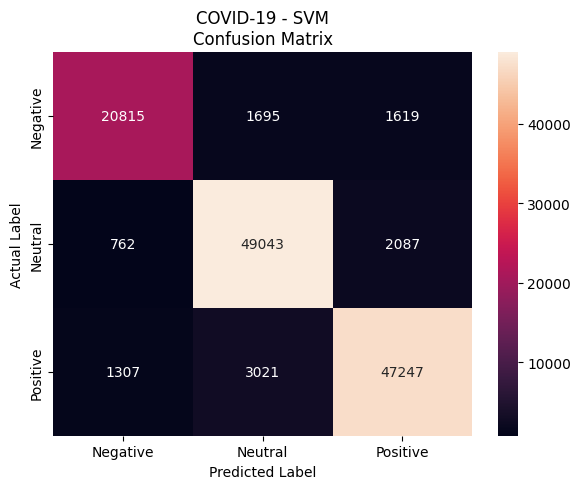

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid19_svm_confusion_matrix.csv

Naive Bayes
[[14661  3020  6448]
 [ 1305 40013 10574]
 [ 1249  4283 46043]]


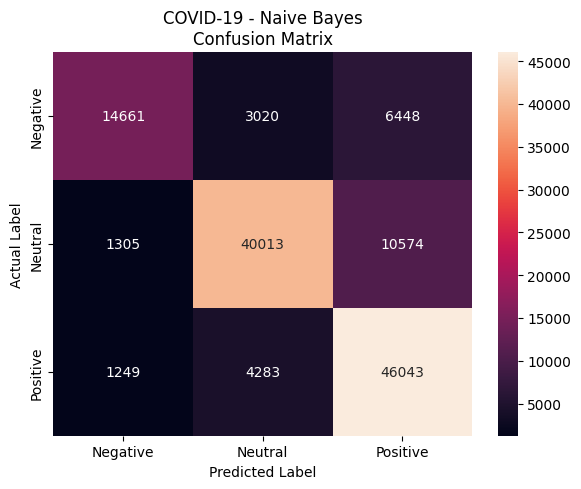

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid19_naive_bayes_confusion_matrix.csv

LSTM
[[23079   450   600]
 [  709 49980  1203]
 [  933  1223 49419]]


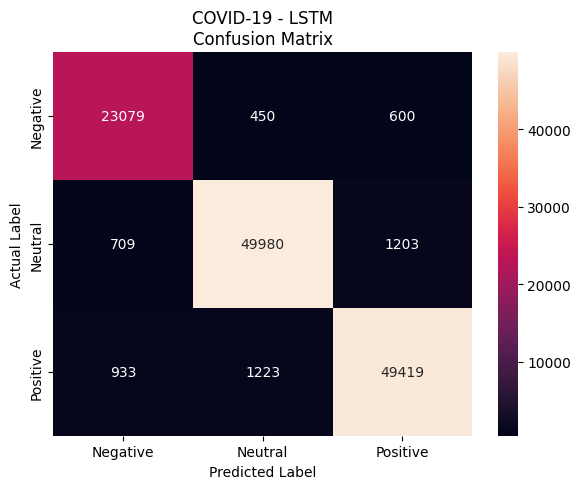

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid19_lstm_confusion_matrix.csv

Demonetization

SVM
[[ 725   27   26]
 [  19 1005   14]
 [  15   41 1116]]


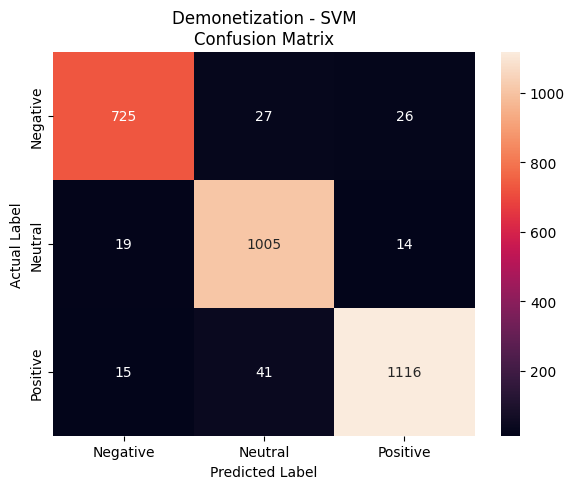

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_svm_confusion_matrix.csv

Naive Bayes
[[ 686   57   35]
 [  39  961   38]
 [  44   74 1054]]


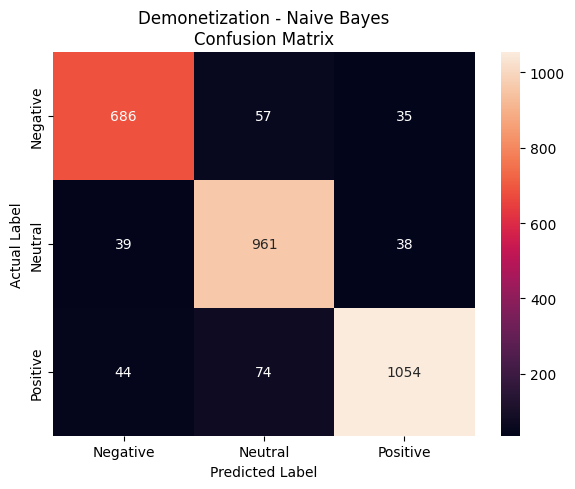

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_naive_bayes_confusion_matrix.csv

LSTM
[[ 651  102   25]
 [  28  996   14]
 [  29   86 1057]]


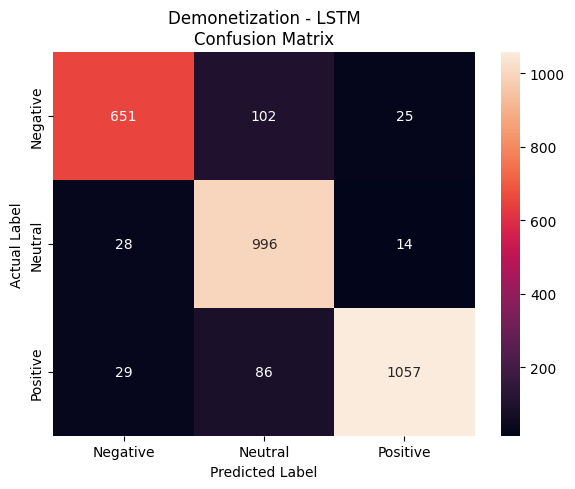

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_lstm_confusion_matrix.csv

CONFUSION MATRIX ANALYSIS COMPLETE


In [74]:
# ================================================================
# CONFUSION MATRICES - FINAL VERSION
# ================================================================

import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

print("=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

RESULTS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/results"
MODELS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/models"

os.makedirs(RESULTS_DIR, exist_ok=True)

# ------------------------------------------------
# LABELS
# ------------------------------------------------

string_labels = ["Negative", "Neutral", "Positive"]
numeric_labels = [0, 1, 2]

print("\nGenerating predictions...")

# ================================================================
# 1. LOAD MODELS
# ================================================================

covid_svm_model = joblib.load(
    os.path.join(MODELS_DIR, "covid_svm.pkl")
)

covid_nb_model = joblib.load(
    os.path.join(MODELS_DIR, "covid_naive_bayes.pkl")
)

covid_lstm_model = tf.keras.models.load_model(
    os.path.join(MODELS_DIR, "covid_lstm_rnn.keras")
)

demo_svm_model = joblib.load(
    os.path.join(MODELS_DIR, "demonetization_svm.pkl")
)

demo_nb_model = joblib.load(
    os.path.join(MODELS_DIR, "demonetization_naive_bayes.pkl")
)

if "demo_rnn_model" not in globals():
    raise NameError(
        "demo_rnn_model is not available. "
        "Run the Demonetization LSTM training cell first."
    )

print("Models loaded successfully.")

# ================================================================
# 2. GENERATE PREDICTIONS
# ================================================================

print("\nCOVID-19 predictions...")

covid_svm_pred = covid_svm_model.predict(X_covid_test)

covid_nb_pred = covid_nb_model.predict(X_covid_test)

covid_lstm_prob = covid_lstm_model.predict(
    X_covid_seq_test,
    verbose=0
)

covid_lstm_pred = np.argmax(covid_lstm_prob, axis=1)

print("COVID-19 predictions completed.")

print("\nDemonetization predictions...")

demo_svm_pred = demo_svm_model.predict(X_demo_test)

demo_nb_pred = demo_nb_model.predict(X_demo_test)

demo_lstm_prob = demo_rnn_model.predict(
    X_demo_seq_test,
    verbose=0
)

demo_lstm_pred = np.argmax(demo_lstm_prob, axis=1)

print("Demonetization predictions completed.")

# ================================================================
# 3. TRUE LABELS
# ================================================================

# SVM and Naive Bayes use string labels
y_covid_ml = np.asarray(y_covid_test)
y_demo_ml = np.asarray(y_demo_test)

# LSTM uses LabelEncoder:
# 0 = Negative
# 1 = Neutral
# 2 = Positive
y_covid_rnn = np.asarray(y_covid_rnn_test)
y_demo_rnn = np.asarray(y_demo_rnn_test)

print("\nLabel types:")
print("COVID SVM/NB:", np.unique(y_covid_ml))
print("COVID LSTM:", np.unique(y_covid_rnn))
print("Demo SVM/NB:", np.unique(y_demo_ml))
print("Demo LSTM:", np.unique(y_demo_rnn))

# ================================================================
# 4. CONFUSION MATRICES
# ================================================================

confusion_matrices = {

    "COVID-19": {

        "SVM": confusion_matrix(
            y_covid_ml,
            covid_svm_pred,
            labels=string_labels
        ),

        "Naive Bayes": confusion_matrix(
            y_covid_ml,
            covid_nb_pred,
            labels=string_labels
        ),

        "LSTM": confusion_matrix(
            y_covid_rnn,
            covid_lstm_pred,
            labels=numeric_labels
        )
    },

    "Demonetization": {

        "SVM": confusion_matrix(
            y_demo_ml,
            demo_svm_pred,
            labels=string_labels
        ),

        "Naive Bayes": confusion_matrix(
            y_demo_ml,
            demo_nb_pred,
            labels=string_labels
        ),

        "LSTM": confusion_matrix(
            y_demo_rnn,
            demo_lstm_pred,
            labels=numeric_labels
        )
    }
}

print("\nAll confusion matrices generated successfully.")

# ================================================================
# 5. DISPLAY + SAVE
# ================================================================

for dataset_name, models in confusion_matrices.items():

    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    dataset_key = (
        dataset_name
        .lower()
        .replace("-", "")
        .replace(" ", "_")
    )

    for model_name, cm in models.items():

        print(f"\n{model_name}")
        print(cm)

        model_key = model_name.lower().replace(" ", "_")

        cm_df = pd.DataFrame(
            cm,
            index=string_labels,
            columns=string_labels
        )

        csv_path = os.path.join(
            RESULTS_DIR,
            f"{dataset_key}_{model_key}_confusion_matrix.csv"
        )

        cm_df.to_csv(csv_path)

        # ------------------------------------------------
        # Plot
        # ------------------------------------------------

        plt.figure(figsize=(6, 5))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            xticklabels=string_labels,
            yticklabels=string_labels
        )

        plt.title(
            f"{dataset_name} - {model_name}\nConfusion Matrix"
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")

        plt.tight_layout()
        plt.show()

        print(f"Saved: {csv_path}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX ANALYSIS COMPLETE")
print("=" * 70)

ROC-AUC ANALYSIS

Loading models...
Models loaded successfully.

Generating COVID-19 probabilities...
COVID-19 probabilities generated.
COVID-19 SVM Macro ROC-AUC: 0.9772


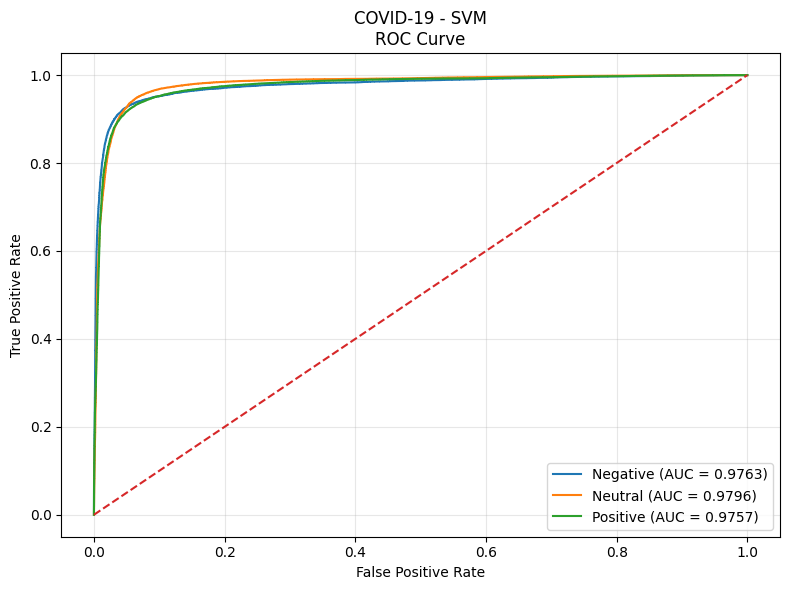

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid_svm_roc_auc.csv
COVID-19 Naive Bayes Macro ROC-AUC: 0.9335


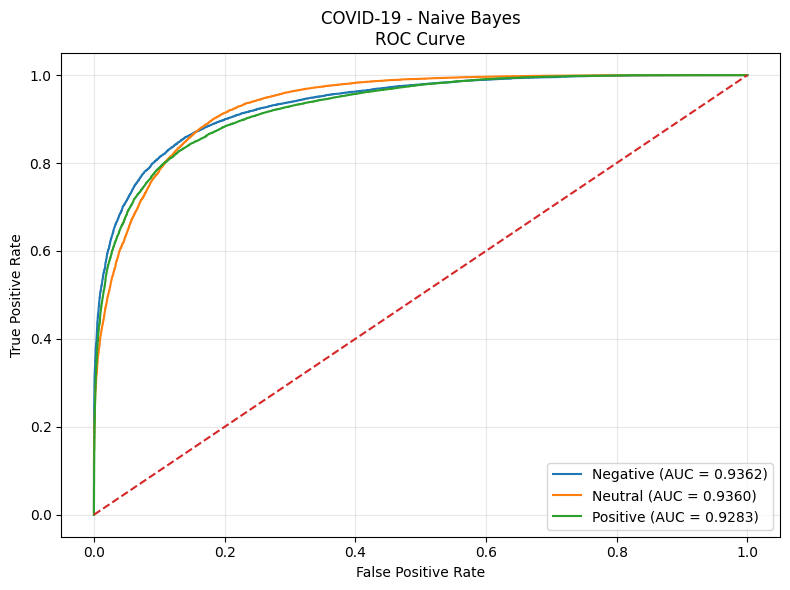

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid_naive_bayes_roc_auc.csv
COVID-19 LSTM Macro ROC-AUC: 0.9927


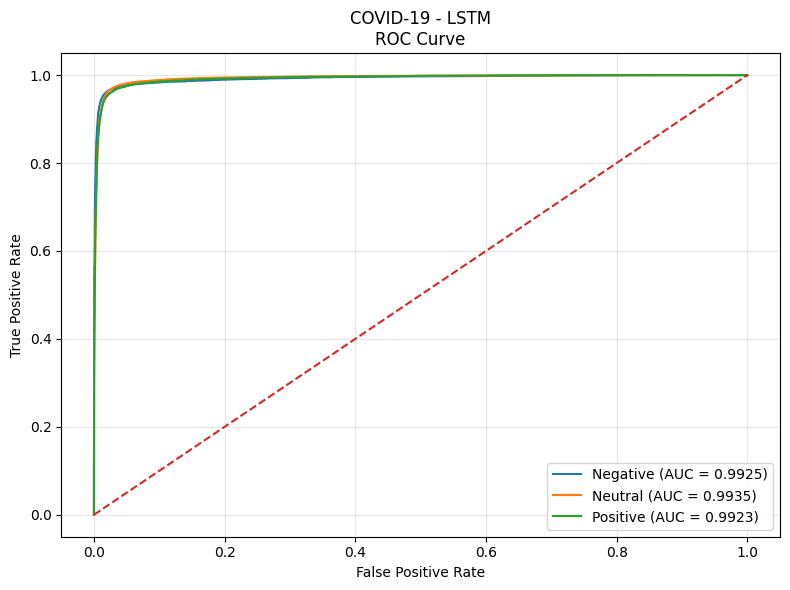

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/covid_lstm_roc_auc.csv

Generating Demonetization probabilities...
Demonetization probabilities generated.
Demonetization SVM Macro ROC-AUC: 0.9952


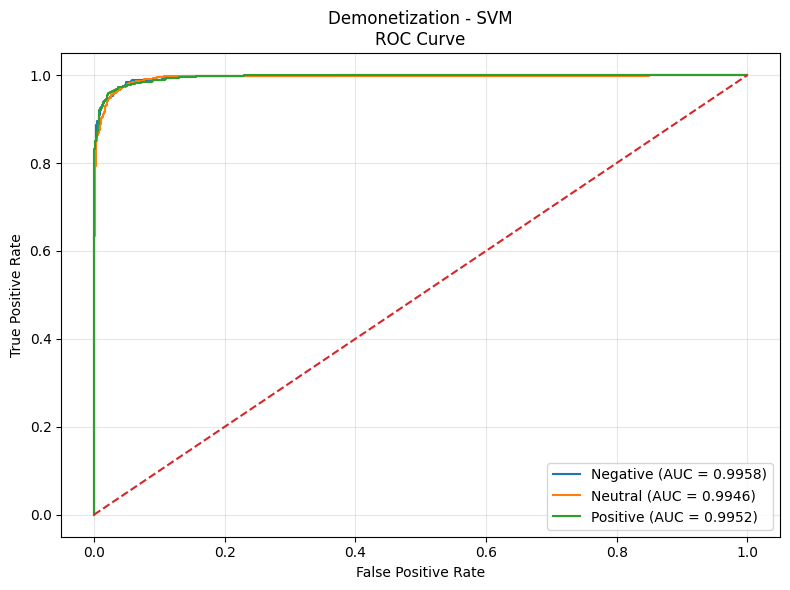

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_svm_roc_auc.csv
Demonetization Naive Bayes Macro ROC-AUC: 0.9845


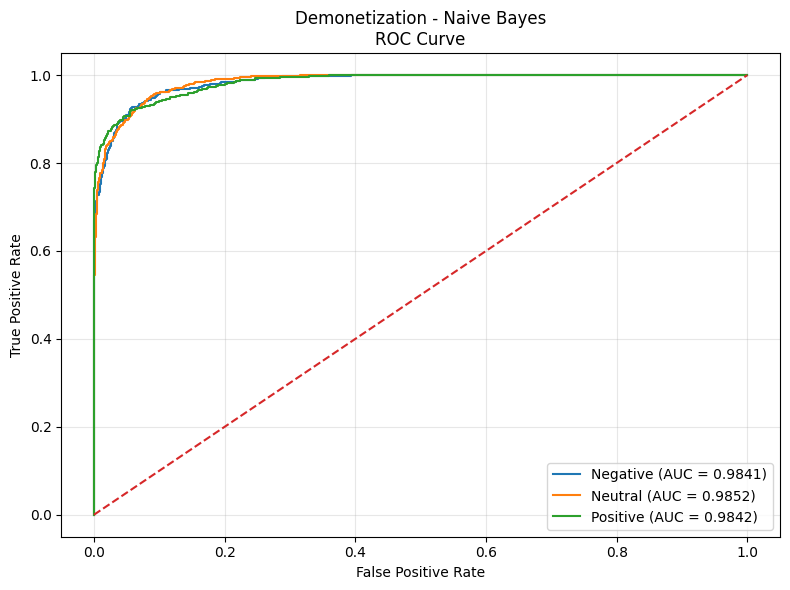

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_naive_bayes_roc_auc.csv
Demonetization LSTM Macro ROC-AUC: 0.9705


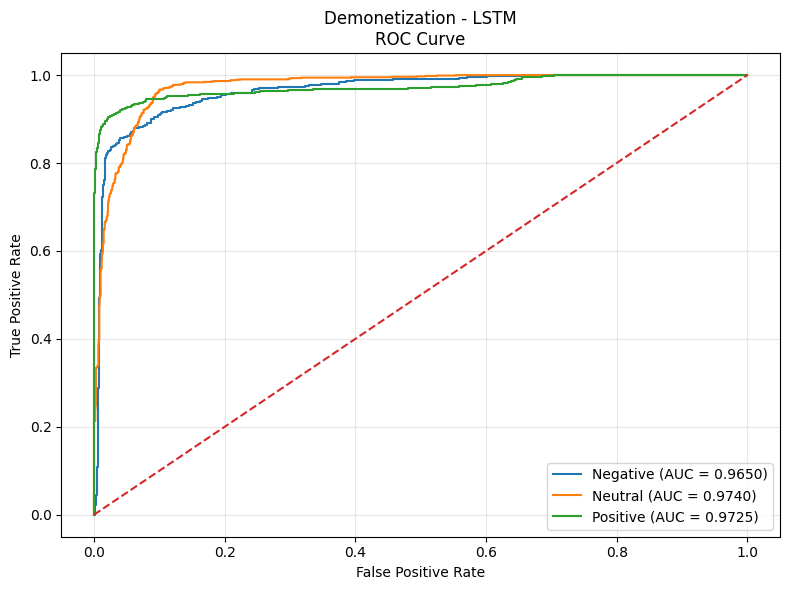

Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/demonetization_lstm_roc_auc.csv

FINAL ROC-AUC SUMMARY


,Dataset,Model,Macro_ROC_AUC
0,COVID-19,SVM,0.9772
1,COVID-19,Naive Bayes,0.9335
2,COVID-19,LSTM,0.9927
3,Demonetization,SVM,0.9952
4,Demonetization,Naive Bayes,0.9845
5,Demonetization,LSTM,0.9705



Saved: /content/NLP_BDA_Twitter_Sentiment_Project/results/final_roc_auc_comparison.csv

ROC-AUC ANALYSIS COMPLETE


In [76]:
# ================================================================
# ROC-AUC ANALYSIS - FINAL FIXED VERSION
# ================================================================

import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("=" * 70)
print("ROC-AUC ANALYSIS")
print("=" * 70)

RESULTS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/results"
MODELS_DIR = "/content/NLP_BDA_Twitter_Sentiment_Project/models"

os.makedirs(RESULTS_DIR, exist_ok=True)

# ================================================================
# CLASS DEFINITIONS
# ================================================================

class_names = ["Negative", "Neutral", "Positive"]

# String labels used by SVM / Naive Bayes
string_labels = np.array([
    "Negative",
    "Neutral",
    "Positive"
])

# Numeric labels used by LSTM
numeric_labels = np.array([0, 1, 2])

# ================================================================
# HELPER FUNCTION
# ================================================================

def calculate_multiclass_roc(
    y_true,
    probabilities,
    classes,
    model_name,
    dataset_name,
    output_prefix
):

    # Convert true labels into binary one-vs-rest format
    y_true_bin = label_binarize(
        y_true,
        classes=classes
    )

    # Macro ROC-AUC
    macro_auc = roc_auc_score(
        y_true_bin,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    print(
        f"{dataset_name} {model_name} "
        f"Macro ROC-AUC: {macro_auc:.4f}"
    )

    # ------------------------------------------------
    # ROC CURVES
    # ------------------------------------------------

    plt.figure(figsize=(8, 6))

    roc_results = []

    for i, class_name in enumerate(class_names):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            probabilities[:, i]
        )

        class_auc = auc(fpr, tpr)

        roc_results.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Class": class_name,
            "AUC": class_auc
        })

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} (AUC = {class_auc:.4f})"
        )

    # Random classifier reference
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"{dataset_name} - {model_name}\nROC Curve"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------
    # SAVE CLASS AUC VALUES
    # ------------------------------------------------

    auc_df = pd.DataFrame(roc_results)

    auc_path = os.path.join(
        RESULTS_DIR,
        f"{output_prefix}_roc_auc.csv"
    )

    auc_df.to_csv(
        auc_path,
        index=False
    )

    print(f"Saved: {auc_path}")

    return macro_auc, auc_df


# ================================================================
# 1. LOAD MODELS
# ================================================================

print("\nLoading models...")

covid_svm_model = joblib.load(
    os.path.join(
        MODELS_DIR,
        "covid_svm.pkl"
    )
)

covid_nb_model = joblib.load(
    os.path.join(
        MODELS_DIR,
        "covid_naive_bayes.pkl"
    )
)

covid_lstm_model = tf.keras.models.load_model(
    os.path.join(
        MODELS_DIR,
        "covid_lstm_rnn.keras"
    )
)

demo_svm_model = joblib.load(
    os.path.join(
        MODELS_DIR,
        "demonetization_svm.pkl"
    )
)

demo_nb_model = joblib.load(
    os.path.join(
        MODELS_DIR,
        "demonetization_naive_bayes.pkl"
    )
)

if "demo_rnn_model" not in globals():

    raise NameError(
        "demo_rnn_model is not available. "
        "Run the Demonetization LSTM training cell first."
    )

print("Models loaded successfully.")


# ================================================================
# 2. COVID-19 PREDICTION PROBABILITIES
# ================================================================

print("\nGenerating COVID-19 probabilities...")

# SVM decision scores → convert to softmax-like probabilities
covid_svm_scores = covid_svm_model.decision_function(
    X_covid_test
)

covid_svm_exp = np.exp(
    covid_svm_scores -
    np.max(covid_svm_scores, axis=1, keepdims=True)
)

covid_svm_prob = (
    covid_svm_exp /
    np.sum(covid_svm_exp, axis=1, keepdims=True)
)

# Ensure probability columns follow:
# Negative, Neutral, Positive

svm_order = list(covid_svm_model.classes_)

covid_svm_prob_ordered = np.column_stack([
    covid_svm_prob[:, svm_order.index("Negative")],
    covid_svm_prob[:, svm_order.index("Neutral")],
    covid_svm_prob[:, svm_order.index("Positive")]
])


# Naive Bayes probabilities
covid_nb_raw = covid_nb_model.predict_proba(
    X_covid_test
)

nb_order = list(covid_nb_model.classes_)

covid_nb_prob = np.column_stack([
    covid_nb_raw[:, nb_order.index("Negative")],
    covid_nb_raw[:, nb_order.index("Neutral")],
    covid_nb_raw[:, nb_order.index("Positive")]
])


# LSTM probabilities
covid_lstm_prob = covid_lstm_model.predict(
    X_covid_seq_test,
    verbose=0
)

print("COVID-19 probabilities generated.")


# ================================================================
# 3. COVID-19 ROC-AUC
# ================================================================

covid_roc_results = []

covid_svm_auc, covid_svm_auc_df = calculate_multiclass_roc(
    y_covid_test,
    covid_svm_prob_ordered,
    string_labels,
    "SVM",
    "COVID-19",
    "covid_svm"
)

covid_nb_auc, covid_nb_auc_df = calculate_multiclass_roc(
    y_covid_test,
    covid_nb_prob,
    string_labels,
    "Naive Bayes",
    "COVID-19",
    "covid_naive_bayes"
)

covid_lstm_auc, covid_lstm_auc_df = calculate_multiclass_roc(
    y_covid_rnn_test,
    covid_lstm_prob,
    numeric_labels,
    "LSTM",
    "COVID-19",
    "covid_lstm"
)


# ================================================================
# 4. DEMONETIZATION PROBABILITIES
# ================================================================

print("\nGenerating Demonetization probabilities...")

# SVM decision scores
demo_svm_scores = demo_svm_model.decision_function(
    X_demo_test
)

demo_svm_exp = np.exp(
    demo_svm_scores -
    np.max(demo_svm_scores, axis=1, keepdims=True)
)

demo_svm_raw_prob = (
    demo_svm_exp /
    np.sum(demo_svm_exp, axis=1, keepdims=True)
)

demo_svm_order = list(
    demo_svm_model.classes_
)

demo_svm_prob = np.column_stack([
    demo_svm_raw_prob[:, demo_svm_order.index("Negative")],
    demo_svm_raw_prob[:, demo_svm_order.index("Neutral")],
    demo_svm_raw_prob[:, demo_svm_order.index("Positive")]
])


# Naive Bayes
demo_nb_raw = demo_nb_model.predict_proba(
    X_demo_test
)

demo_nb_order = list(
    demo_nb_model.classes_
)

demo_nb_prob = np.column_stack([
    demo_nb_raw[:, demo_nb_order.index("Negative")],
    demo_nb_raw[:, demo_nb_order.index("Neutral")],
    demo_nb_raw[:, demo_nb_order.index("Positive")]
])


# LSTM
demo_lstm_prob = demo_rnn_model.predict(
    X_demo_seq_test,
    verbose=0
)

print("Demonetization probabilities generated.")


# ================================================================
# 5. DEMONETIZATION ROC-AUC
# ================================================================

demo_svm_auc, demo_svm_auc_df = calculate_multiclass_roc(
    y_demo_test,
    demo_svm_prob,
    string_labels,
    "SVM",
    "Demonetization",
    "demonetization_svm"
)

demo_nb_auc, demo_nb_auc_df = calculate_multiclass_roc(
    y_demo_test,
    demo_nb_prob,
    string_labels,
    "Naive Bayes",
    "Demonetization",
    "demonetization_naive_bayes"
)

demo_lstm_auc, demo_lstm_auc_df = calculate_multiclass_roc(
    y_demo_rnn_test,
    demo_lstm_prob,
    numeric_labels,
    "LSTM",
    "Demonetization",
    "demonetization_lstm"
)


# ================================================================
# 6. FINAL ROC-AUC SUMMARY
# ================================================================

roc_summary = pd.DataFrame({

    "Dataset": [
        "COVID-19",
        "COVID-19",
        "COVID-19",
        "Demonetization",
        "Demonetization",
        "Demonetization"
    ],

    "Model": [
        "SVM",
        "Naive Bayes",
        "LSTM",
        "SVM",
        "Naive Bayes",
        "LSTM"
    ],

    "Macro_ROC_AUC": [
        covid_svm_auc,
        covid_nb_auc,
        covid_lstm_auc,
        demo_svm_auc,
        demo_nb_auc,
        demo_lstm_auc
    ]
})

roc_summary["Macro_ROC_AUC"] = roc_summary[
    "Macro_ROC_AUC"
].round(4)

print("\n" + "=" * 70)
print("FINAL ROC-AUC SUMMARY")
print("=" * 70)

display(roc_summary)

roc_summary_path = os.path.join(
    RESULTS_DIR,
    "final_roc_auc_comparison.csv"
)

roc_summary.to_csv(
    roc_summary_path,
    index=False
)

print(f"\nSaved: {roc_summary_path}")

print("\n" + "=" * 70)
print("ROC-AUC ANALYSIS COMPLETE")
print("=" * 70)